### Enable importing modules from the parent project directory
 --> (e.g., for running this script from subfolders like /scripts or /notebooks)

In [56]:
import sys
import os
sys.path.append(os.path.abspath(".."))  # Adds project root

### Importing necessary libraries

In [57]:
import pandas as pd  # Data manipulation and DataFrame support
import numpy as np  # Numerical computing with arrays
import math  # Basic mathematical functions
import matplotlib.pyplot as plt  # Plotting and visualization
from sklearn.metrics import mean_squared_error, mean_absolute_error  # Evaluation metrics
from statistics import mode  # Compute statistical mode
import folium  # Interactive maps (leaflet.js-based)
from folium.plugins import MarkerCluster  # Cluster markers on maps
from scipy.stats import pearsonr  # Pearson correlation calculation
from sklearn.preprocessing import StandardScaler  # Z-score normalization
from sklearn.preprocessing import MinMaxScaler  # Scale features to 0–1 range
from tqdm import tqdm  # Progress bars for loops
from prophet import Prophet  # Facebook Prophet time series forecasting
import random  # Random number generation
from sklearn.impute import SimpleImputer  # Basic missing value imputation
from typing import Dict  # Type hinting for dictionaries
import seaborn as sns  # Statistical data visualization
from sklearn.impute import SimpleImputer  # (Duplicate) Basic imputation again
from IPython.display import display, HTML  # Pretty HTML display in notebooks
from sklearn.decomposition import PCA  # Principal Component Analysis (dimensionality reduction)
from sklearn.preprocessing import StandardScaler  # (Duplicate) Z-score scaling
from statsmodels.tsa.holtwinters import ExponentialSmoothing  # Time series smoothing & forecasting
from sklearn.ensemble import RandomForestRegressor  # Random Forest for regression tasks
from sklearn.inspection import permutation_importance  # Feature importance via permutation
import warnings  # Control warning messages
warnings.filterwarnings("ignore")  # Suppress warnings (useful in notebooks)
from prophet.plot import plot_plotly, plot_components_plotly  # Plotting Prophet results
from prophet.diagnostics import cross_validation, performance_metrics  # Prophet diagnostics tools

In [58]:
from typing import List, Tuple  # Type hinting for lists and tuples

from Algorithms.CDREC import CDRec  # Collaborative Denoising for matrix completion
from Algorithms.TKCM import TKCM  # Top-k Case Matching (basic version)
from Algorithms.TKCM_Weighted import TKCM_Weighted  # TKCM with similarity-based weighting
from Algorithms.DynaMMO import DynaMMo  # Dynamic Matrix Modeling for time series imputation
from Algorithms.SoftImpute import SoftImpute  # Low-rank matrix completion using soft-thresholding
from Algorithms.SVDImpute import IterativeSVD  # Iterative SVD-based matrix imputation
from Algorithms.trmf import TRMFImputer  # Temporal Regularized Matrix Factorization
from Algorithms.ST_MVL import ST_MVL  # Space-Time Matrix-Vector Learning
from Algorithms.TKCM_PLUS import TKCM_PLUS  # TKCM variant with alpha–beta blending, also using Target series known values to fill the missing values
from Algorithms.TKCM_PRO import TKCM_PRO  # Pro version of TKCM with anchor filtering, here averaging the refrence to fill the missing values


### Loading the Dataset

In [59]:

mountain_df = pd.read_csv("D:\\Thesis\\Project\\Data\\mountain_data.csv")

# Counting the different types of missingness in the dataset
stats = {
    "Total Rows": len(mountain_df),
    "Total Columns": len(mountain_df.columns),
    "Zero Values": (mountain_df == 0).sum().sum(),
    "NaN Values": mountain_df.isna().sum().sum(),
    "Blank Strings": (mountain_df == "").sum().sum(),
    "Unknown Strings": (mountain_df.applymap(lambda x: isinstance(x, str) and x.strip().lower() == "unknown")).sum().sum()
}

# Return as DataFrame
stats_df = pd.DataFrame(list(stats.items()), columns=["Metric", "Value"])
stats_df


,Metric,Value
0,Total Rows,2785482
1,Total Columns,6
2,Zero Values,96350
3,NaN Values,0
4,Blank Strings,0
5,Unknown Strings,0


#### Displaying the first 5 rows of the data

In [60]:
mountain_df.head()

,station_code,sensor_code,description_it,unit,timestamp,value
0,45200SF,LT,Temperatura dell´aria,°C,2025-01-01 00:00:00,-2.1
1,45200SF,LT,Temperatura dell´aria,°C,2024-12-31 23:30:00,-0.8
2,45200SF,LT,Temperatura dell´aria,°C,2024-12-31 23:00:00,-2.2
3,45200SF,LT,Temperatura dell´aria,°C,2024-12-31 22:30:00,-0.6
4,45200SF,LT,Temperatura dell´aria,°C,2024-12-31 22:00:00,-1.0


### Displaying column-wise metadata

##### Includes:
- Total number of entries
- Column names and types
- Non-null counts
- Memory usage

In [61]:
mountain_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2785482 entries, 0 to 2785481
Data columns (total 6 columns):
 #   Column          Dtype  
---  ------          -----  
 0   station_code    object 
 1   sensor_code     object 
 2   description_it  object 
 3   unit            object 
 4   timestamp       object 
 5   value           float64
dtypes: float64(1), object(5)
memory usage: 127.5+ MB


### describe() provide us with statistical summary of numeric columns
#### Includes:
- Count, mean, std deviation
- Min, 25%, 50%, 75%, and max values

In [62]:
mountain_df.describe()

,value
count,2.785482e+06
mean,5.304164e+01
std,8.350127e+01
min,-2.460000e+01
25%,1.200000e+00
50%,8.200000e+00
75%,7.700000e+01
max,3.660000e+02


In [63]:
# Preview data
print("🔍 Shape:", mountain_df.shape)

🔍 Shape: (2785482, 6)


In [64]:
# Check which columns are non-numeric
print("🧠 Columns in the file:\n", mountain_df.dtypes)

🧠 Columns in the file:
 station_code       object
sensor_code        object
description_it     object
unit               object
timestamp          object
value             float64
dtype: object


### Checking all the unique sensor codes i have in this dataset

In [65]:
unique_values = mountain_df['sensor_code'].unique()
unique_values

array(['LT', 'WR', 'WG', 'WG.BOE', 'LF', 'HS', 'N'], dtype=object)

### checking unique similar station_codes

In [66]:
unique_values1 = mountain_df['station_code'].unique()
unique_values1

array(['45200SF', '82500WS', '45100WS', '00700WS', '00390SF', '06040WS',
       '06090SF', '35100WS', '50400WS', '50360SF', '61690SF', '61720WS',
       '20720WS', '20690SF', '91210WS', '91180SF', '24300SF', '78480SF',
       '15000SF', '34200WS', '31810SF', '66000WS', '66100SF', '80100SF',
       '90005SF', '15050WS', '07740WS', '15590SF', '01080SF', '20050SF',
       '35205SF', '24170WS', '53200SF', '42830SF', '62270SF', '02700SF'],
      dtype=object)

### Looking at the descriptions of the sensor what is meaning of those sensor codes

In [67]:
unique_values2 = mountain_df['description_it'].unique()
unique_values2

array(['Temperatura dell´aria', 'Direzione del vento',
       'Velocità del vento', 'Velocitá raffica', 'Umidità relativa',
       'Altezza neve al suolo', 'Precipitazioni'], dtype=object)

### checking unit of data values

In [68]:
unique_values3 = mountain_df['unit'].unique()
unique_values3

array(['°C', '° ', 'm/s', '%', 'cm', 'mm'], dtype=object)

### looking at unique values

In [69]:
unique_values4 = mountain_df['value'].unique()
unique_values4

array([ -2.1,  -0.8,  -2.2, ..., 327.3, 366. , 365. ], shape=(3847,))

### Checking the columns i have and how they pronounced

In [70]:
column_names = list(mountain_df.columns)
column_names

['station_code', 'sensor_code', 'description_it', 'unit', 'timestamp', 'value']

### counting the zeroes and sum them 

In [71]:
zero_counts = (mountain_df == 0).sum()
print(zero_counts)

station_code          0
sensor_code           0
description_it        0
unit                  0
timestamp             0
value             96350
dtype: int64


### displaying the values with zeroes

In [72]:
mountain_df[mountain_df["value"] == 0].head()

,station_code,sensor_code,description_it,unit,timestamp,value
38,45200SF,LT,Temperatura dell´aria,°C,2024-12-31 05:00:00,0.0
57,45200SF,LT,Temperatura dell´aria,°C,2024-12-30 19:30:00,0.0
93,45200SF,LT,Temperatura dell´aria,°C,2024-12-30 01:30:00,0.0
247,45200SF,LT,Temperatura dell´aria,°C,2024-12-26 20:30:00,0.0
1403,45200SF,LT,Temperatura dell´aria,°C,2024-12-02 18:30:00,0.0


#### checking if values are numeric, if yes then add percentage to the zeroes and sort them by percentage of zero they contain. 

In [73]:
# Make sure 'value' is numeric
mountain_df['value'] = pd.to_numeric(mountain_df['value'], errors='coerce')

# Group by sensor_code
zero_stats = (
    mountain_df.groupby('sensor_code')
    .agg(
        total_entries=('value', 'count'),
        zero_count=('value', lambda x: (x == 0).sum())
    )
)

# Add percentage of zeros
zero_stats['zero_percentage'] = (zero_stats['zero_count'] / zero_stats['total_entries']) * 100

# Sort by percentage of zero values
zero_stats = zero_stats.sort_values(by='zero_percentage', ascending=False)

print(zero_stats.reset_index())


  sensor_code  total_entries  zero_count  zero_percentage
0           N           3165        3085        97.472354
1          WG         485833       45854         9.438223
2      WG.BOE         485834       37041         7.624209
3          WR         486667        5332         1.095616
4          LT         502908        3974         0.790204
5          HS         318145        1064         0.334439
6          LF         502930           0         0.000000


In [74]:
# Step 1: Select sensor `LF`
lf_df = mountain_df[mountain_df['sensor_code'] == 'LF'].copy()

In [75]:
# Step 2: Replace `0.0` values with NaN
lf_df.loc[lf_df['value'] == 0.0, 'value'] = np.nan

In [76]:
# Step 3: Pivot to wide format (timestamp × station_code)
lf_df['timestamp'] = pd.to_datetime(lf_df['timestamp'])
pivot_df = lf_df.pivot(index='timestamp', columns='station_code', values='value')

In [77]:
# Step 4: Drop sparse stations (>10% missing)
threshold = 0.9 * len(pivot_df)
pivot_df = pivot_df.dropna(thresh=threshold, axis=1)

In [78]:
# Step 5: Drop rows with any missing values
clean_df = pivot_df.dropna(axis=0)

#### Displaying the clean dataframe to check what i have with me.

In [79]:
clean_df

station_code,00390SF,00700WS,01080SF,02700SF,06090SF,07740WS,15000SF,15590SF,20050SF,20690SF,...,61720WS,62270SF,66000WS,66100SF,78480SF,80100SF,82500WS,90005SF,91180SF,91210WS
timestamp,,,,,,,,,,,,,,,,,,,,,
2023-01-01 00:00:00,91.7,83.5,67.7,71.4,56.7,75.7,62.0,96.6,79.1,84.6,...,71.3,78.6,85.2,99.8,91.4,99.0,100.5,100.5,89.0,80.2
2023-01-01 00:30:00,92.9,73.0,71.3,75.9,66.2,69.4,64.0,96.5,83.0,89.0,...,55.0,77.5,87.0,99.8,88.6,99.0,100.5,100.5,100.0,78.2
2023-01-01 01:00:00,93.2,77.3,69.0,68.7,58.7,78.3,62.0,96.6,85.6,99.0,...,53.6,74.9,88.6,99.8,88.8,99.0,100.5,100.4,100.0,72.8
2023-01-01 01:30:00,96.3,65.8,70.5,63.9,64.2,77.1,56.0,96.7,85.9,94.1,...,51.9,78.6,91.0,99.8,99.0,99.0,100.5,100.5,99.9,68.7
2023-01-01 02:00:00,96.5,80.2,71.5,69.6,63.6,78.8,60.0,97.3,84.6,95.9,...,54.1,82.7,92.9,99.8,99.4,99.0,100.5,100.5,99.6,67.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 22:00:00,55.8,23.1,24.6,37.8,20.7,22.9,16.0,45.2,28.7,30.4,...,16.9,31.0,20.7,44.0,36.4,40.8,46.6,44.8,43.3,24.4
2024-12-31 22:30:00,58.5,22.9,24.5,34.3,19.8,23.4,17.0,45.5,31.4,30.8,...,20.5,30.3,19.6,43.1,35.2,39.9,43.7,37.6,44.4,25.2
2024-12-31 23:00:00,57.9,23.2,23.7,34.7,17.8,24.4,16.0,44.6,35.0,31.7,...,19.4,29.7,19.7,44.8,37.1,41.1,44.8,39.4,43.2,25.7


In [80]:
# Step 6: Pick a target station 
target_station = clean_df.columns[2]

#### displaying target station

In [81]:
target_station

'01080SF'

In [82]:
# Step 7: Computing Pearson correlations 
correlations = clean_df.corr()[target_station].drop(index=target_station).sort_values(ascending=False)

### displaying correlations

In [83]:
correlations

station_code
02700SF    0.905750
07740WS    0.883122
15000SF    0.882522
66000WS    0.859966
20720WS    0.858887
06090SF    0.842800
00700WS    0.839848
24170WS    0.823065
61720WS    0.822564
20050SF    0.806652
53200SF    0.801489
00390SF    0.798884
45100WS    0.793957
50360SF    0.793274
42830SF    0.788832
62270SF    0.782693
34200WS    0.782484
80100SF    0.780221
20690SF    0.779346
91210WS    0.764497
66100SF    0.754209
31810SF    0.752281
45200SF    0.745443
82500WS    0.737315
35100WS    0.724453
35205SF    0.718820
78480SF    0.712181
61690SF    0.704324
24300SF    0.691944
15590SF    0.686211
91180SF    0.672880
90005SF    0.645907
Name: 01080SF, dtype: float64

In [84]:

# Step 8: Select top 2 correlated reference stations
top_refs = correlations.head(2).index.tolist()
final_df = clean_df[[target_station] + top_refs].copy()

In [85]:
top_refs

['02700SF', '07740WS']

#### Checking the final dataframe

In [86]:
final_df

station_code,01080SF,02700SF,07740WS
timestamp,,,
2023-01-01 00:00:00,67.7,71.4,75.7
2023-01-01 00:30:00,71.3,75.9,69.4
2023-01-01 01:00:00,69.0,68.7,78.3
2023-01-01 01:30:00,70.5,63.9,77.1
2023-01-01 02:00:00,71.5,69.6,78.8
...,...,...,...
2024-12-31 22:00:00,24.6,37.8,22.9
2024-12-31 22:30:00,24.5,34.3,23.4
2024-12-31 23:00:00,23.7,34.7,24.4


In [87]:
# Step 8: Build new DataFrame with target and top 3 references
top_3_refs = correlations.dropna().sort_values(ascending=False).head(3).index.tolist()
selected_stations = [target_station] + top_3_refs
pattern_df = pivot_df[selected_stations].copy()

In [88]:
pattern_df

station_code,01080SF,02700SF,07740WS,15000SF
timestamp,,,,
2023-01-01 00:00:00,67.7,71.4,75.7,62.0
2023-01-01 00:30:00,71.3,75.9,69.4,64.0
2023-01-01 01:00:00,69.0,68.7,78.3,62.0
2023-01-01 01:30:00,70.5,63.9,77.1,56.0
2023-01-01 02:00:00,71.5,69.6,78.8,60.0
...,...,...,...,...
2024-12-31 22:00:00,24.6,37.8,22.9,16.0
2024-12-31 22:30:00,24.5,34.3,23.4,17.0
2024-12-31 23:00:00,23.7,34.7,24.4,16.0


#### Plotting target station with reference stations

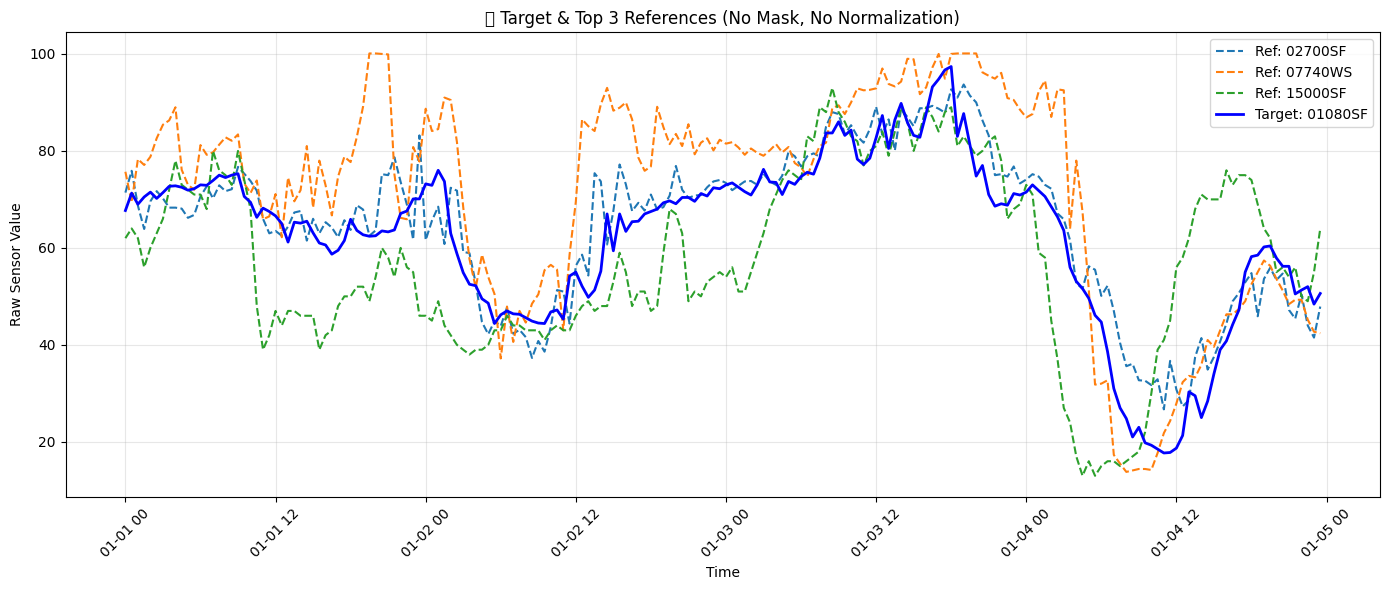

In [89]:
# Define the stations 
target = "01080SF"  # Target station
# References are the top 3 correlated stations
references = ["02700SF","07740WS","15000SF"]

# Defining time range for plot (e.g., Jan 1 to Jan 4, 2023)
start_time = "2023-01-01"
end_time = "2023-01-04"

# Slicing the DataFrame
plot_df = pattern_df[[target] + references].loc[start_time:end_time].copy()

# Plotting
plt.figure(figsize=(14, 6))

# Plotting the reference series
for ref in references:
    plt.plot(plot_df.index, plot_df[ref], linestyle='--', label=f"Ref: {ref}")

# Plotting the target series
plt.plot(plot_df.index, plot_df[target], color='blue', linewidth=2, label=f"Target: {target}")

plt.xlabel("Time")
plt.ylabel("Raw Sensor Value")
plt.title("📍 Target & Top 3 References (No Mask, No Normalization)")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


# -------------------------------------------
# 🔹 STEP 1: Normalizing the Time Series Data
# -------------------------------------------

In [90]:
from sklearn.preprocessing import StandardScaler

#  Initialize the Scaler
scaler = StandardScaler()

#  Fitting the scaler on the full pattern_df and transform it
normalized_array = scaler.fit_transform(pattern_df)

#  Reconstruct a DataFrame with the same shape, columns, and index
normalized_df = pd.DataFrame(
    normalized_array,
    columns=pattern_df.columns,
    index=pattern_df.index
)

#  Print shape and preview
print(" Normalized shape:", normalized_df.shape)
display(normalized_df.head())


 Normalized shape: (14592, 4)


station_code,01080SF,02700SF,07740WS,15000SF
timestamp,,,,
2023-01-01 00:00:00,0.332066,0.442973,0.549643,-0.019616
2023-01-01 00:30:00,0.476635,0.623380,0.320728,0.053217
2023-01-01 01:00:00,0.384271,0.334729,0.644115,-0.019616
2023-01-01 01:30:00,0.444508,0.142294,0.600513,-0.238116
2023-01-01 02:00:00,0.484666,0.370810,0.662283,-0.092449


-> What This Does:
- Performs z-score normalization: subtracts the mean, divides by standard deviation
- Ensures each sensor has mean 0 and std 1
- Prevents scale bias in distance-based algorithms such as TKCM, CDRec, ST_MVL
- here, we can use normalized_df[target_station] for masking, and all columns for reference

STEP 2: Inject Block-Missing Values in the Middle of the Target Series
I’ll define a function that injects a block of NaNs in the middle of the target time series (from normalized_df[target_station]), and 
This will keep track of:
- The masked series
- The block’s start and end index
- The corresponding true values for evaluation

# ---------------------------------------------------------
# 🔹 STEP 2: Defining function to the inject block-missing in the middle
# ---------------------------------------------------------

In [91]:
def introduce_block_missing_middle(series: pd.Series, block_length: int) -> Tuple[pd.Series, int, int]:
    """
    Introduce a block of NaN values into the middle of a time series.

    Parameters:
        series (pd.Series): The original time series (normalized)
        block_length (int): The number of consecutive values to mask

    Returns:
        masked_series (pd.Series): The modified series with NaNs
        start_idx (int): Starting index of the missing block
        end_idx (int): Ending index (exclusive) of the missing block
    """
    ts = series.copy()
    mid_start = len(ts) // 2 - block_length // 2
    mid_end = mid_start + block_length
    ts[mid_start:mid_end] = np.nan
    return ts, mid_start, mid_end


# ---------------------------------------------------------
# 🔹 STEP 2b: Applying block-missing to the normalized target series
# ---------------------------------------------------------

In [92]:
# Define target station 
target_station = "01080SF"

# Define block length (e.g. 10 time points ~ 5 hours if half-hourly)
block_length = 721

# Apply the masking function
masked_target, start_idx, end_idx = introduce_block_missing_middle(
    normalized_df[target_station],
    block_length
)

# Print info about the block
print(f"🧱 Missing block injected from index {start_idx} to {end_idx - 1}")
print("🕓 Timestamps of missing block:\n", normalized_df.index[start_idx:end_idx])


🧱 Missing block injected from index 6936 to 7656
🕓 Timestamps of missing block:
 DatetimeIndex(['2023-12-28 12:30:00', '2023-12-28 13:00:00',
               '2023-12-28 13:30:00', '2023-12-28 14:00:00',
               '2023-12-28 14:30:00', '2023-12-28 15:00:00',
               '2023-12-28 15:30:00', '2023-12-28 16:00:00',
               '2023-12-28 16:30:00', '2023-12-28 17:00:00',
               ...
               '2024-01-12 08:00:00', '2024-01-12 08:30:00',
               '2024-01-12 09:00:00', '2024-01-12 09:30:00',
               '2024-01-12 10:00:00', '2024-01-12 10:30:00',
               '2024-01-12 11:00:00', '2024-01-12 11:30:00',
               '2024-01-12 12:00:00', '2024-01-12 12:30:00'],
              dtype='datetime64[ns]', name='timestamp', length=721, freq=None)


📦 STEP 3: Convert to NumPy Arrays & Prepare Evaluation Inputs

-> This includes:

- Masked target series (with middle block removed)
- Reference matrix (fully observed, already normalized)
- True values from the masked block (for MAE/RMSE)
- Indices of the masked values

# ---------------------------------------------------------
# 🔹 STEP 3: Preparing NumPy arrays for imputation and evaluation
# ---------------------------------------------------------

In [93]:
#  Extracting the reference station names (excluding the target)
reference_stations = [col for col in normalized_df.columns if col != target_station]

#  Getting reference matrix as shape (num_refs, time) — transposed
ref_matrix = normalized_df[reference_stations].to_numpy().T  # shape: (num_refs, time)

#  Getting the masked target series as array (shape: time,)
masked_target_array = masked_target.to_numpy().copy()

#  Getting the original (true) unmasked target series
true_target_array = normalized_df[target_station].to_numpy()

#  Saving the index positions of the block-masked values
nan_block_indices = np.arange(start_idx, end_idx)

#  Preview shapes and sanity check
print(" Target shape:", masked_target_array.shape)
print(" Ref matrix shape:", ref_matrix.shape)
print(" Block indices:", nan_block_indices)
print(" Target preview (with NaNs):", masked_target_array[start_idx:end_idx])


 Target shape: (14592,)
 Ref matrix shape: (3, 14592)
 Block indices: [6936 6937 6938 6939 6940 6941 6942 6943 6944 6945 6946 6947 6948 6949
 6950 6951 6952 6953 6954 6955 6956 6957 6958 6959 6960 6961 6962 6963
 6964 6965 6966 6967 6968 6969 6970 6971 6972 6973 6974 6975 6976 6977
 6978 6979 6980 6981 6982 6983 6984 6985 6986 6987 6988 6989 6990 6991
 6992 6993 6994 6995 6996 6997 6998 6999 7000 7001 7002 7003 7004 7005
 7006 7007 7008 7009 7010 7011 7012 7013 7014 7015 7016 7017 7018 7019
 7020 7021 7022 7023 7024 7025 7026 7027 7028 7029 7030 7031 7032 7033
 7034 7035 7036 7037 7038 7039 7040 7041 7042 7043 7044 7045 7046 7047
 7048 7049 7050 7051 7052 7053 7054 7055 7056 7057 7058 7059 7060 7061
 7062 7063 7064 7065 7066 7067 7068 7069 7070 7071 7072 7073 7074 7075
 7076 7077 7078 7079 7080 7081 7082 7083 7084 7085 7086 7087 7088 7089
 7090 7091 7092 7093 7094 7095 7096 7097 7098 7099 7100 7101 7102 7103
 7104 7105 7106 7107 7108 7109 7110 7111 7112 7113 7114 7115 7116 7117
 7118 7

# -----------------------------------------------
# 🔹 STEP 4.1: Setting safe parameters for all models
# -----------------------------------------------

In [94]:
k = 5  # number of top matching sequences (for TKCMs)
l = 4  # sliding window size
rank = max(1, min(ref_matrix.shape[0] - 1, 2))  # safe low-rank dimension for SVD, TRMF


# -----------------------------------------------
# 🔹 STEP 4.2: Applying each model with correct usage
# -----------------------------------------------

In [95]:
# Stack the masked target (first row) + full reference matrix (rest)
X_stacked = np.vstack([masked_target_array, ref_matrix])

#  TKCM
tkcm = TKCM(k=k, l=l)
tkcm_imputed = tkcm.impute(masked_target_array.copy(), offset=start_idx, ref_ts=ref_matrix)

#  TKCM_Weighted
tkcm_w = TKCM_Weighted(k=k, l=l)
tkcm_weighted_imputed = tkcm_w.impute(masked_target_array.copy(), offset=start_idx, ref_ts=ref_matrix)

#  TKCM_PLUS
tkcm_plus = TKCM_PLUS(k=k, l=l, alpha=0.5, beta=0.5)
tkcm_plus_imputed = tkcm_plus.impute(masked_target_array.copy(), offset=start_idx, ref_ts=ref_matrix)


#  TKCM_PRO
tkcm_pro = TKCM_PRO(k=k, l=l)
tkcm_pro_imputed = tkcm_pro.impute(masked_target_array.copy(), offset=start_idx, ref_ts=ref_matrix)


#  CDRec
cdrec = CDRec(rank=rank)
cdrec_imputed = cdrec.impute(X_stacked.copy())[0]  # Only return target row

#  DynaMMo
dynammo = DynaMMo(latent_dim=rank)
dynammo_imputed = dynammo.fit_transform(X_stacked.copy())[0]

# SoftImpute
soft = SoftImpute(max_rank=rank)
soft_imputed = soft.fit_transform(X_stacked.copy())[0]

#  IterativeSVD
svd = IterativeSVD(rank=rank)
svd_imputed = svd.fit_transform(X_stacked.copy())[0]

#  ST_MVL
st_mvl = ST_MVL()
st_mvl_imputed = st_mvl.impute(X_stacked.copy())[0]

# TRMF
trmf = TRMFImputer(rank=rank)
trmf_imputed = trmf.fit_transform(X_stacked.copy())[0]


In [96]:
# In TKCM imputation loop
missing_indices = np.where(np.isnan(masked_target_array))[0]

for offset in missing_indices:
    imputed_series = tkcm.impute(masked_target_array.copy(), offset=offset, ref_ts=ref_matrix)
    print(f"Offset {offset} → Imputed value = {imputed_series[offset]}")


Offset 2140 → Imputed value = -1.519221983093233
Offset 6936 → Imputed value = -1.571427489328927
Offset 6937 → Imputed value = -1.5336788925123481
Offset 6938 → Imputed value = -1.4959302956957696
Offset 6939 → Imputed value = -1.456575375610401
Offset 6940 → Imputed value = -1.4493469209008432
Offset 6941 → Imputed value = -1.484686032814236
Offset 6942 → Imputed value = -1.214574424840191
Offset 6943 → Imputed value = -1.4790639013734688
Offset 6944 → Imputed value = -1.2622102600867413
Offset 6945 → Imputed value = -1.1312949136803094
Offset 6946 → Imputed value = -1.1786814501096317
Offset 6947 → Imputed value = -1.026883901208922
Offset 6948 → Imputed value = -0.6812750996017207
Offset 6949 → Imputed value = -0.841907426480778
Offset 6950 → Imputed value = -1.2212490167325816
Offset 6951 → Imputed value = -1.1425391765618436
Offset 6952 → Imputed value = -1.1401296916586576
Offset 6953 → Imputed value = -1.1859099048191892
Offset 6954 → Imputed value = -1.1200506507987753
Offset 

# ---------------------------------------------------------
# 🔹 STEP 5: Evaluating all imputation methods (Middle Block)
# ---------------------------------------------------------

In [97]:
results_block = []

# True values for the missing block
true_vals = true_target_array[start_idx:end_idx]
missing_indices = np.arange(start_idx, end_idx)

# Helper to evaluate predictions against true values
def evaluate_direct(name, imputed_array):
    try:
        predicted = imputed_array[start_idx:end_idx]
        mae = np.mean(np.abs(predicted - true_vals))
        rmse = np.sqrt(np.mean((predicted - true_vals) ** 2))
        results_block.append({
            "Method": name,
            "MAE": round(mae, 4),
            "RMSE": round(rmse, 4),
            "First Imputed": round(predicted[0], 4),
            "Last Imputed": round(predicted[-1], 4),
            "First True": round(true_vals[0], 4),
            "Last True": round(true_vals[-1], 4),
            "Missing Block": "Middle"
        })
    except Exception as e:
        results_block.append({
            "Method": name,
            "MAE": "NaN",
            "RMSE": "NaN",
            "First Imputed": "NaN",
            "Last Imputed": "NaN",
            "First True": round(true_vals[0], 4),
            "Last True": round(true_vals[-1], 4),
            "Missing Block": "Middle"
        })

# TKCM (loop over all missing indices)
try:
    tkcm_imputed = masked_target_array.copy()
    for offset in missing_indices:
        tkcm_imputed = TKCM(k=k, l=l).impute(tkcm_imputed, offset=offset, ref_ts=ref_matrix)
    evaluate_direct("TKCM", tkcm_imputed)
except Exception as e:
    print(" TKCM failed:", e)
    evaluate_direct("TKCM", np.full_like(true_vals, np.nan))

#  TKCM_Weighted (loop over all missing indices)
try:
    tkcm_weighted_imputed = masked_target_array.copy()
    for offset in missing_indices:
        tkcm_weighted_imputed = TKCM_Weighted(k=k, l=l).impute(tkcm_weighted_imputed, offset=offset, ref_ts=ref_matrix)
    evaluate_direct("TKCM_Weighted", tkcm_weighted_imputed)
except Exception as e:
    print(" TKCM_Weighted failed:", e)
    evaluate_direct("TKCM_Weighted", np.full_like(true_vals, np.nan))
    
#  TKCM_PLUS (loop over all missing indices)
try:
    tkcm_plus_imputed = masked_target_array.copy()
    for offset in missing_indices:
        tkcm_plus_imputed = TKCM_PLUS(k=k, l=l, alpha=0.5, beta=0.5).impute(
            tkcm_plus_imputed, offset=offset, ref_ts=ref_matrix
        )
    evaluate_direct("TKCM_PLUS", tkcm_plus_imputed)
except Exception as e:
    print(" TKCM_PLUS failed:", e)
    evaluate_direct("TKCM_PLUS", np.full_like(true_vals, np.nan))

#  TKCM_PRO (loop over all missing indices)
try:
    tkcm_pro_imputed = masked_target_array.copy()
    for offset in missing_indices:
        tkcm_pro_imputed = TKCM_PRO(k=k, l=l).impute(
            tkcm_pro_imputed, offset=offset, ref_ts=ref_matrix
        )
    evaluate_direct("TKCM_PRO", tkcm_pro_imputed)
except Exception as e:
    print(" TKCM_PRO failed:", e)
    evaluate_direct("TKCM_PRO", np.full_like(true_vals, np.nan))
    




#  Other models 
evaluate_direct("CDRec", cdrec_imputed)
evaluate_direct("DynaMMo", dynammo_imputed)
evaluate_direct("SoftImpute", soft_imputed)
evaluate_direct("SVDImpute", svd_imputed)

#  ST_MVL — remove NaNs from references
try:
    X_stmv = X_stacked.copy()
    X_stmv[1:, :] = np.nan_to_num(X_stmv[1:, :])
    st_mvl_model = ST_MVL()
    st_mvl_imputed = st_mvl_model.impute(X_stmv)[0]
    evaluate_direct("ST_MVL", st_mvl_imputed)
except Exception as e:
    print("ST_MVL failed:", e)
    evaluate_direct("ST_MVL", np.full_like(true_vals, np.nan))

# TRMF — fixed implementation
try:
    X_trmf_input = X_stacked.T.copy()
    observed_mask = ~np.isnan(X_stacked.T)
    X_trmf_input = np.nan_to_num(X_trmf_input, nan=0.0).astype(np.float64)
    trmf_model = TRMFImputer(rank=rank, lag_idx=[1, 2, 3])
    trmf_model.fit(X_trmf_input, observed_mask)
    X_trmf_output = trmf_model.transform()
    trmf_imputed = X_trmf_output[:, 0]
    evaluate_direct("TRMF", trmf_imputed)
except Exception as e:
    print(" TRMF failed:", e)
    evaluate_direct("TRMF", np.full_like(true_vals, np.nan))

# Final Results Display
results_df = pd.DataFrame(results_block)
display(results_df.style.background_gradient(cmap="YlGnBu", subset=["MAE", "RMSE"]))


,Method,MAE,RMSE,First Imputed,Last Imputed,First True,Last True,Missing Block
0,TKCM,0.351700,0.443900,-1.571400,-0.685500,-1.499100,-0.732100,Middle
1,TKCM_Weighted,0.353200,0.445700,-1.570200,-0.662000,-1.499100,-0.732100,Middle
2,TKCM_PLUS,0.697800,0.819000,-0.940900,-0.000000,-1.499100,-0.732100,Middle
3,TKCM_PRO,1.683000,1.944000,-4.460600,-2.649400,-1.499100,-0.732100,Middle
4,CDRec,0.327200,0.447400,-1.487500,-0.900000,-1.499100,-0.732100,Middle
5,DynaMMo,0.327700,0.448500,-1.495100,-0.909000,-1.499100,-0.732100,Middle
6,SoftImpute,0.323300,0.441700,-1.462200,-0.889800,-1.499100,-0.732100,Middle
7,SVDImpute,0.329600,0.451200,-1.505000,-0.910300,-1.499100,-0.732100,Middle
8,ST_MVL,0.449400,0.586400,-1.549100,-0.529400,-1.499100,-0.732100,Middle
9,TRMF,0.318000,0.413300,-1.023000,-0.769300,-1.499100,-0.732100,Middle


### RMSE Comparison of Imputation Methods

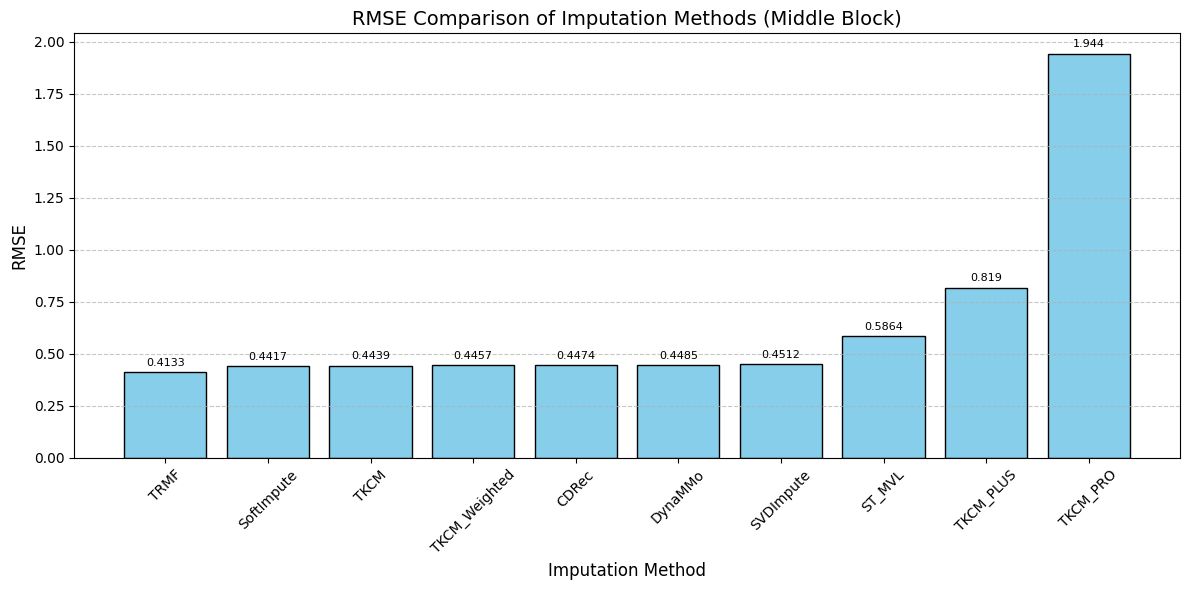

In [98]:
# Sort methods by RMSE ascending for better visual comparison
results_sorted = results_df.sort_values(by="RMSE").reset_index(drop=True)

# Plot settings
fig, ax = plt.subplots(figsize=(12, 6))

# Bar chart
bars = ax.bar(results_sorted["Method"], results_sorted["RMSE"], color="skyblue", edgecolor="black")

# Annotate RMSE values on top of bars
for bar, rmse in zip(bars, results_sorted["RMSE"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02, f"{rmse}", 
            ha="center", va="bottom", fontsize=8)

# Labels and title
ax.set_title("RMSE Comparison of Imputation Methods (Middle Block)", fontsize=14)
ax.set_xlabel("Imputation Method", fontsize=12)
ax.set_ylabel("RMSE", fontsize=12)
ax.grid(axis="y", linestyle="--", alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### MAE Comparison Of Imputation Methods

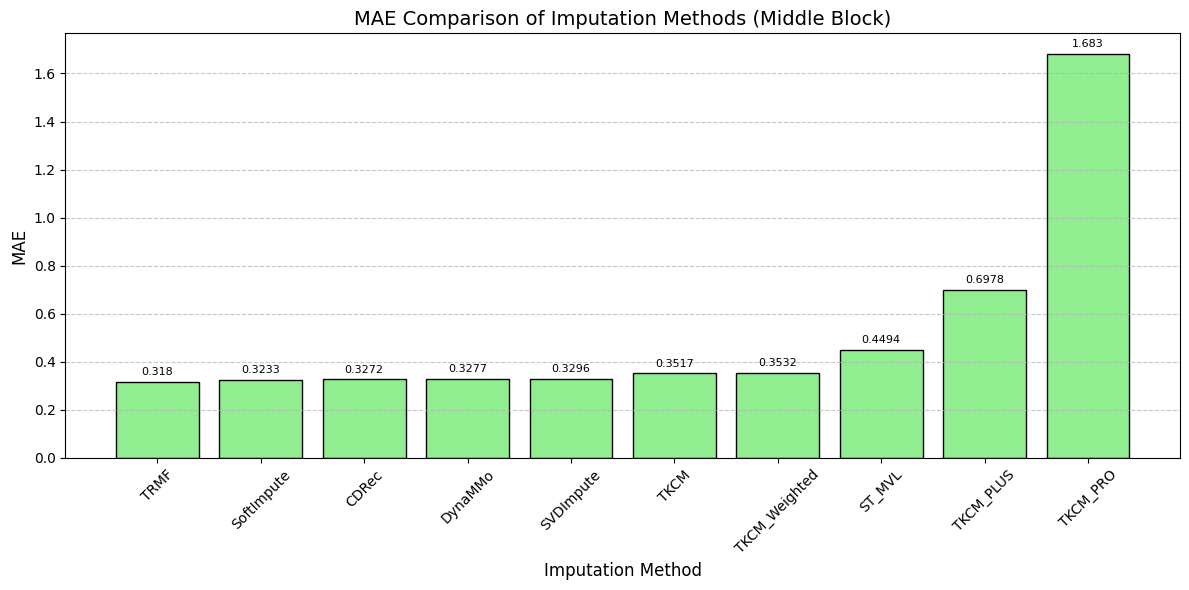

In [99]:
# Sort by MAE
results_sorted_mae = results_df.sort_values(by="MAE").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(results_sorted_mae["Method"], results_sorted_mae["MAE"], color="lightgreen", edgecolor="black")

for bar, mae in zip(bars, results_sorted_mae["MAE"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02, f"{mae}", 
            ha="center", va="bottom", fontsize=8)

ax.set_title("MAE Comparison of Imputation Methods (Middle Block)", fontsize=14)
ax.set_xlabel("Imputation Method", fontsize=12)
ax.set_ylabel("MAE", fontsize=12)
ax.grid(axis="y", linestyle="--", alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Line Chart Implementation of all the algorithms

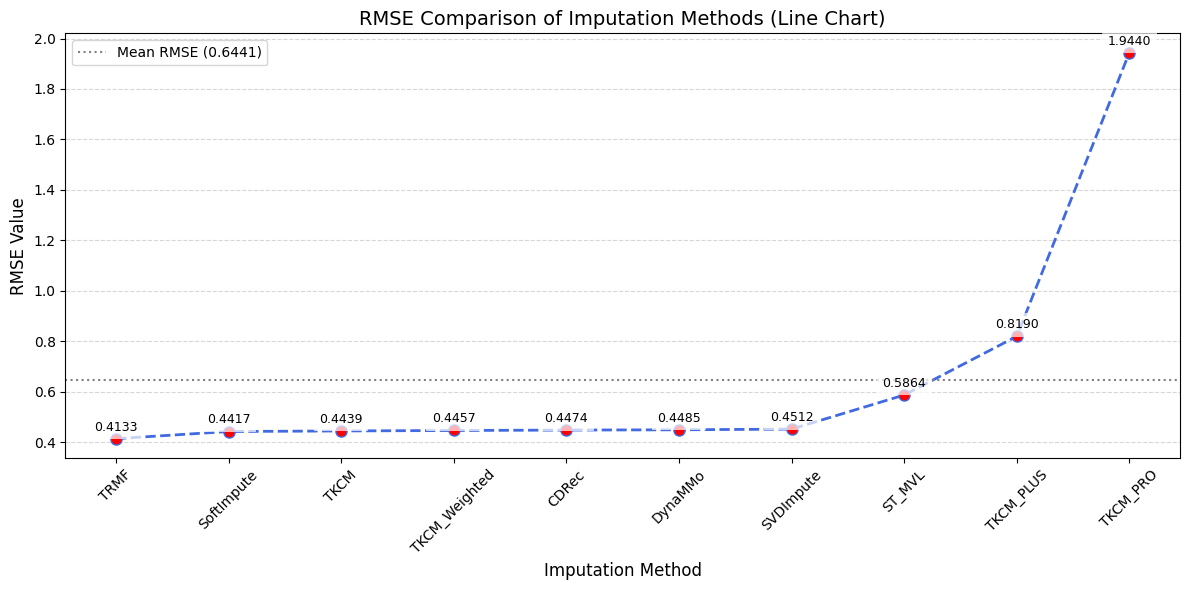

In [100]:
# Line chart implementation
plt.figure(figsize=(12, 6))

# Create line plot with markers
line = plt.plot(results_sorted["Method"], 
                results_sorted["RMSE"], 
                marker='o', 
                markersize=8,
                linestyle='--',
                color='royalblue',
                linewidth=2,
                markerfacecolor='red')

# Annotate each point with RMSE value
for x, y in zip(range(len(results_sorted)), results_sorted["RMSE"]):
    plt.text(x, y+0.02, f"{y:.4f}", 
             ha='center', 
             va='bottom',
             fontsize=9,
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

# Add reference line for visual comparison
plt.axhline(y=results_sorted["RMSE"].mean(), 
            color='gray', 
            linestyle=':', 
            label=f'Mean RMSE ({results_sorted["RMSE"].mean():.4f})')

# Chart formatting
plt.title("RMSE Comparison of Imputation Methods (Line Chart)", fontsize=14)
plt.xlabel("Imputation Method", fontsize=12)
plt.ylabel("RMSE Value", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.legend()

# Ensure proper layout
plt.tight_layout()
plt.show()

### Applying Facebook Prophet to forecast future values based on the imputed time series.
     - Prepares data in Prophet format
     - Fits the model with daily and yearly seasonality
     - Forecasts next 48 hourly values (2 days)
     - Plots both forecast and seasonal components


### Simulating a dataset similar to the context of my imputation results

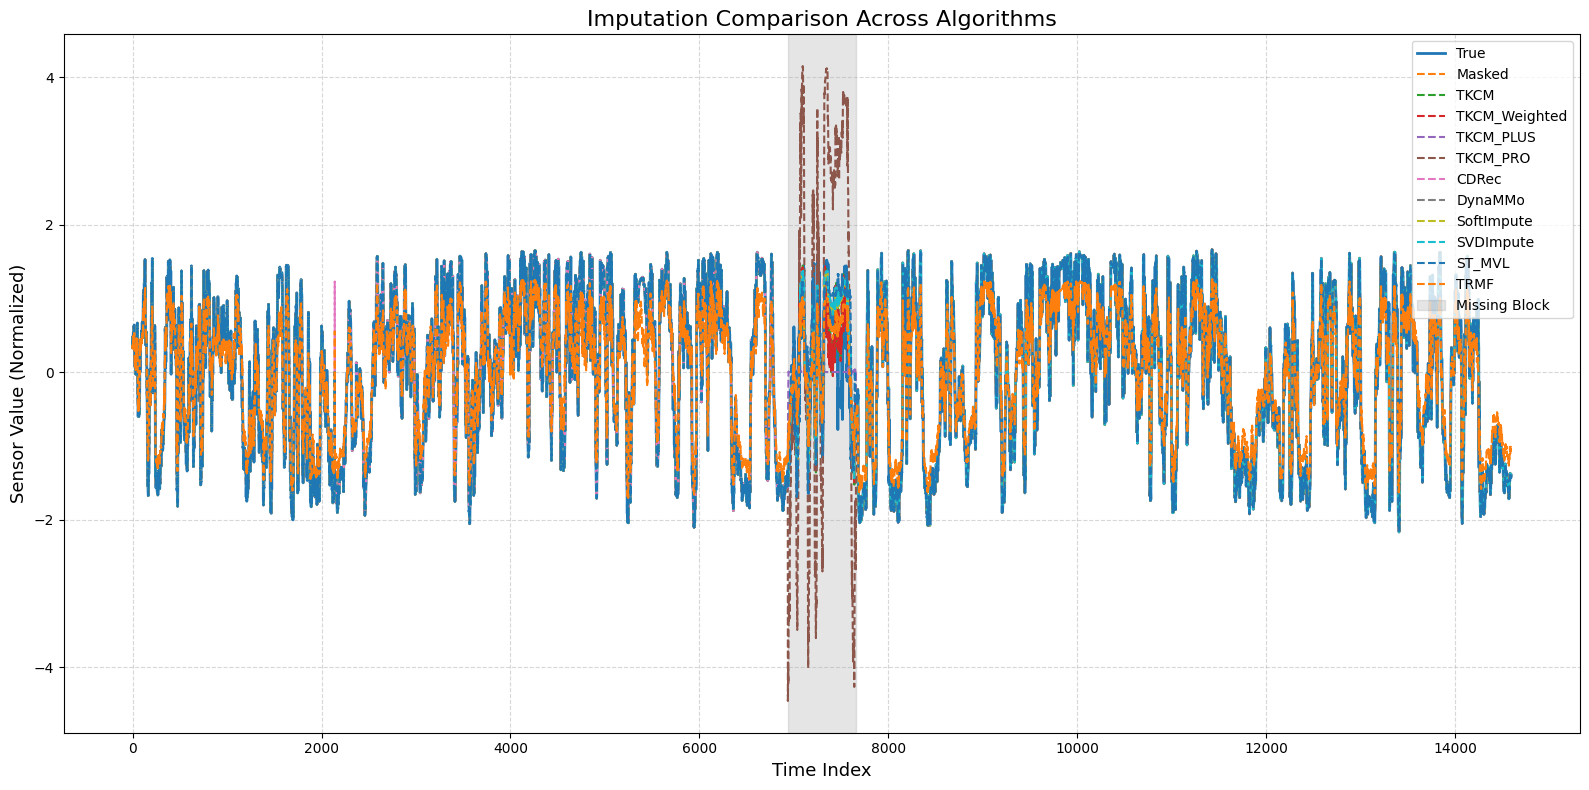

In [101]:
# Time axis based on the actual data length
time = np.arange(len(true_target_array))

# Dictionary of imputed results from your real benchmark
imputed_data_real = {
    "True": true_target_array,
    "Masked": masked_target_array,
    "TKCM": tkcm_imputed,
    "TKCM_Weighted": tkcm_weighted_imputed,
    "TKCM_PLUS": tkcm_plus_imputed,
    "TKCM_PRO": tkcm_pro_imputed,
    "CDRec": cdrec_imputed,
    "DynaMMo": dynammo_imputed,
    "SoftImpute": soft_imputed,
    "SVDImpute": svd_imputed,
    "ST_MVL": st_mvl_imputed,
    "TRMF": trmf_imputed,
}

# Plotting
plt.figure(figsize=(16, 8))
for method, series in imputed_data_real.items():
    linestyle = "-" if method == "True" else "--"
    linewidth = 2 if method == "True" else 1.5
    plt.plot(time, series, label=method, linestyle=linestyle, linewidth=linewidth)

# Highlight missing block
plt.axvspan(start_idx, end_idx, color="gray", alpha=0.2, label="Missing Block")

# Labels and styling
plt.title("Imputation Comparison Across Algorithms", fontsize=16)
plt.xlabel("Time Index", fontsize=13)
plt.ylabel("Sensor Value (Normalized)", fontsize=13)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


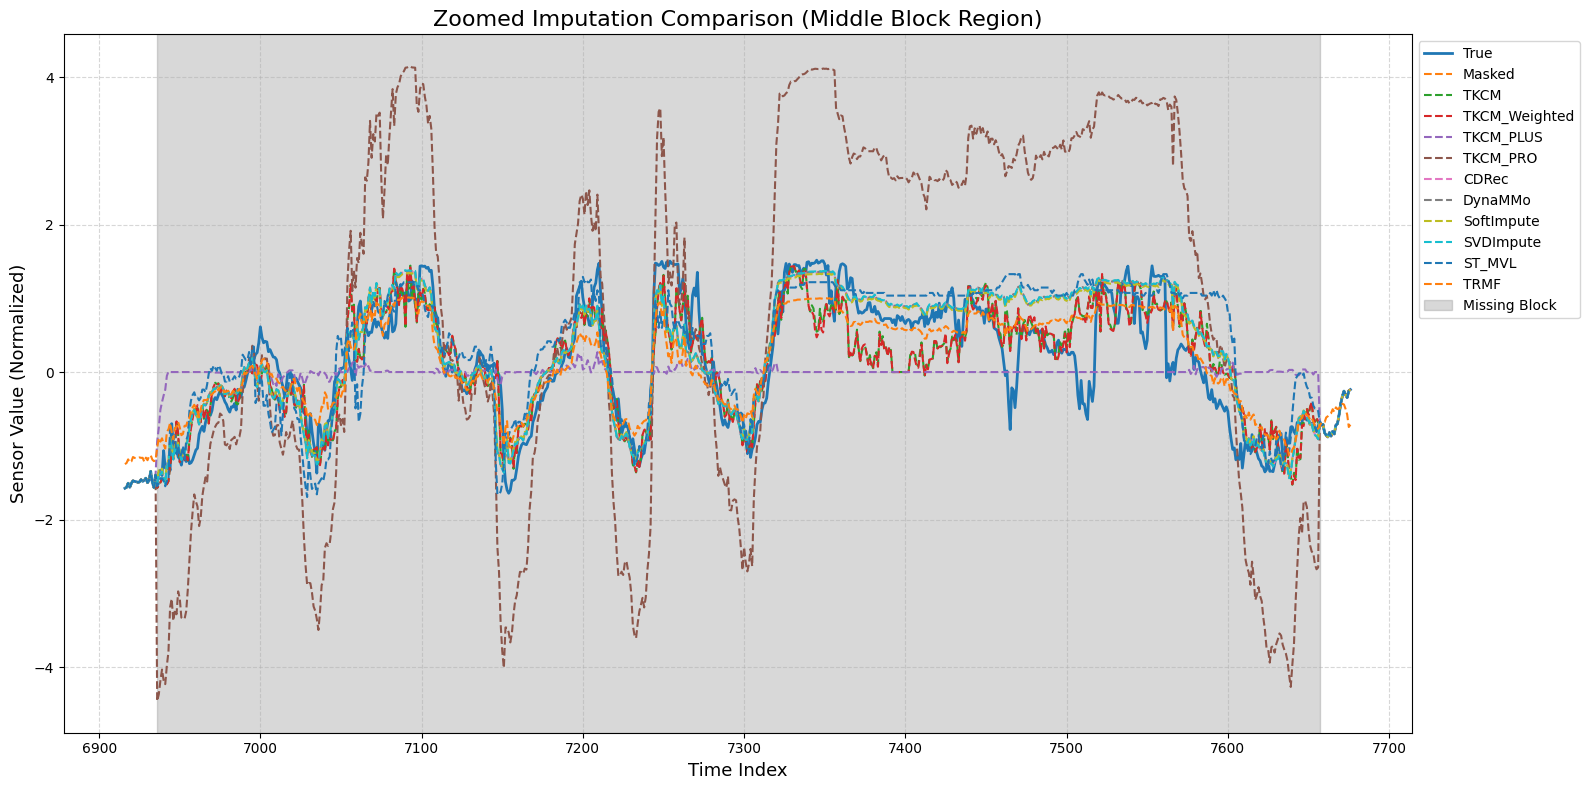

In [102]:
# Define zoom window around missing block
zoom_start = max(0, start_idx - 20)
zoom_end = min(len(true_target_array), end_idx + 20)
time_zoom = np.arange(zoom_start, zoom_end)

# Prepare the zoomed versions of each series
imputed_data_zoom = {
    "True": true_target_array[zoom_start:zoom_end],
    "Masked": masked_target_array[zoom_start:zoom_end],
    "TKCM": tkcm_imputed[zoom_start:zoom_end],
    "TKCM_Weighted": tkcm_weighted_imputed[zoom_start:zoom_end],
    "TKCM_PLUS": tkcm_plus_imputed[zoom_start:zoom_end],
    "TKCM_PRO": tkcm_pro_imputed[zoom_start:zoom_end],
    "CDRec": cdrec_imputed[zoom_start:zoom_end],
    "DynaMMo": dynammo_imputed[zoom_start:zoom_end],
    "SoftImpute": soft_imputed[zoom_start:zoom_end],
    "SVDImpute": svd_imputed[zoom_start:zoom_end],
    "ST_MVL": st_mvl_imputed[zoom_start:zoom_end],
    "TRMF": trmf_imputed[zoom_start:zoom_end],
}

# Plotting zoomed comparison
plt.figure(figsize=(16, 8))
for method, series in imputed_data_zoom.items():
    linestyle = "-" if method == "True" else "--"
    linewidth = 2 if method == "True" else 1.5
    plt.plot(time_zoom, series, label=method, linestyle=linestyle, linewidth=linewidth)

# Highlight missing block within zoomed range
plt.axvspan(start_idx, end_idx, color="gray", alpha=0.3, label="Missing Block")

# Final touches
plt.title("Zoomed Imputation Comparison (Middle Block Region)", fontsize=16)
plt.xlabel("Time Index", fontsize=13)
plt.ylabel("Sensor Value (Normalized)", fontsize=13)
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


✅ TKCM, TKCM_Weighted, TKCM_PLUS, CDRec, DynaMMo, SoftImpute
→ These seem to follow the true blue line relatively well, especially for the shape and fluctuation.

❌ ST_MVL
→ Its brown dashed line is clearly overreacting — with spikes up to ±4, deviating heavily from the real signal. Likely overfitting or unable to handle block missingness well.

⚠️ TRMF (orange dashed)
→ Flat line in many places. Possibly failing to reconstruct dynamics or maybe needs better parameter tuning (lag or rank).

📉 Masked line
→ Flat during the missing block (expected), which visually shows you where the algorithms are imputing.

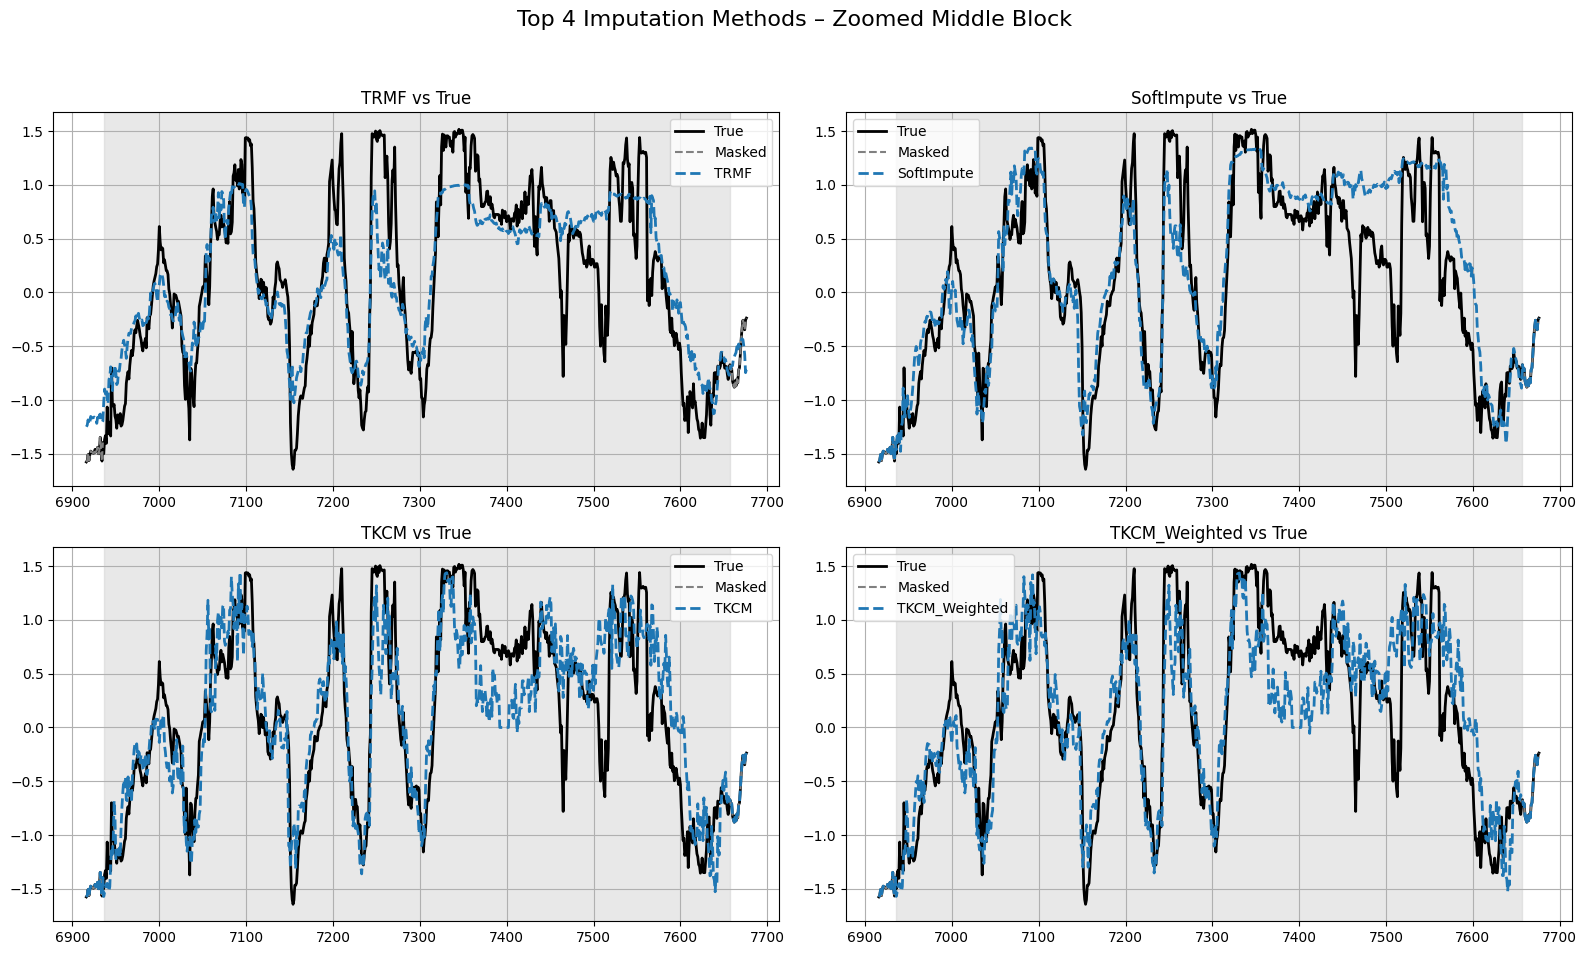

In [103]:
# Mapping between method names and their actual variable names
imputed_series_map = {
    "TKCM": tkcm_imputed,
    "TKCM_Weighted": tkcm_weighted_imputed,
    "TKCM_PLUS": tkcm_plus_imputed,
    "TKCM_PRO": tkcm_pro_imputed,
    "CDRec": cdrec_imputed,
    "DynaMMo": dynammo_imputed,
    "SoftImpute": soft_imputed,
    "SVDImpute": svd_imputed,
    "ST_MVL": st_mvl_imputed,
    "TRMF": trmf_imputed
}

# Sort by RMSE and get top 4 methods
top_methods = results_df.sort_values(by="RMSE")["Method"].tolist()
top_methods = [m for m in top_methods if m not in ["True", "Masked"]][:4]

# Zoom range
zoom_start = max(0, start_idx - 20)
zoom_end = min(len(true_target_array), end_idx + 20)
time_zoom = np.arange(zoom_start, zoom_end)

# Plot 2x2 subplots
fig, axs = plt.subplots(2, 2, figsize=(16, 10))
axs = axs.flatten()

for i, method in enumerate(top_methods):
    axs[i].plot(time_zoom, true_target_array[zoom_start:zoom_end], label="True", color="black", linewidth=2)
    axs[i].plot(time_zoom, masked_target_array[zoom_start:zoom_end], label="Masked", color="gray", linestyle="--")

    if method in imputed_series_map:
        axs[i].plot(time_zoom, imputed_series_map[method][zoom_start:zoom_end], 
                    label=method, linestyle="--", linewidth=2)

    axs[i].axvspan(start_idx, end_idx, color="lightgray", alpha=0.5)
    axs[i].set_title(f"{method} vs True", fontsize=12)
    axs[i].legend()
    axs[i].grid(True)

plt.suptitle("Top 4 Imputation Methods – Zoomed Middle Block", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


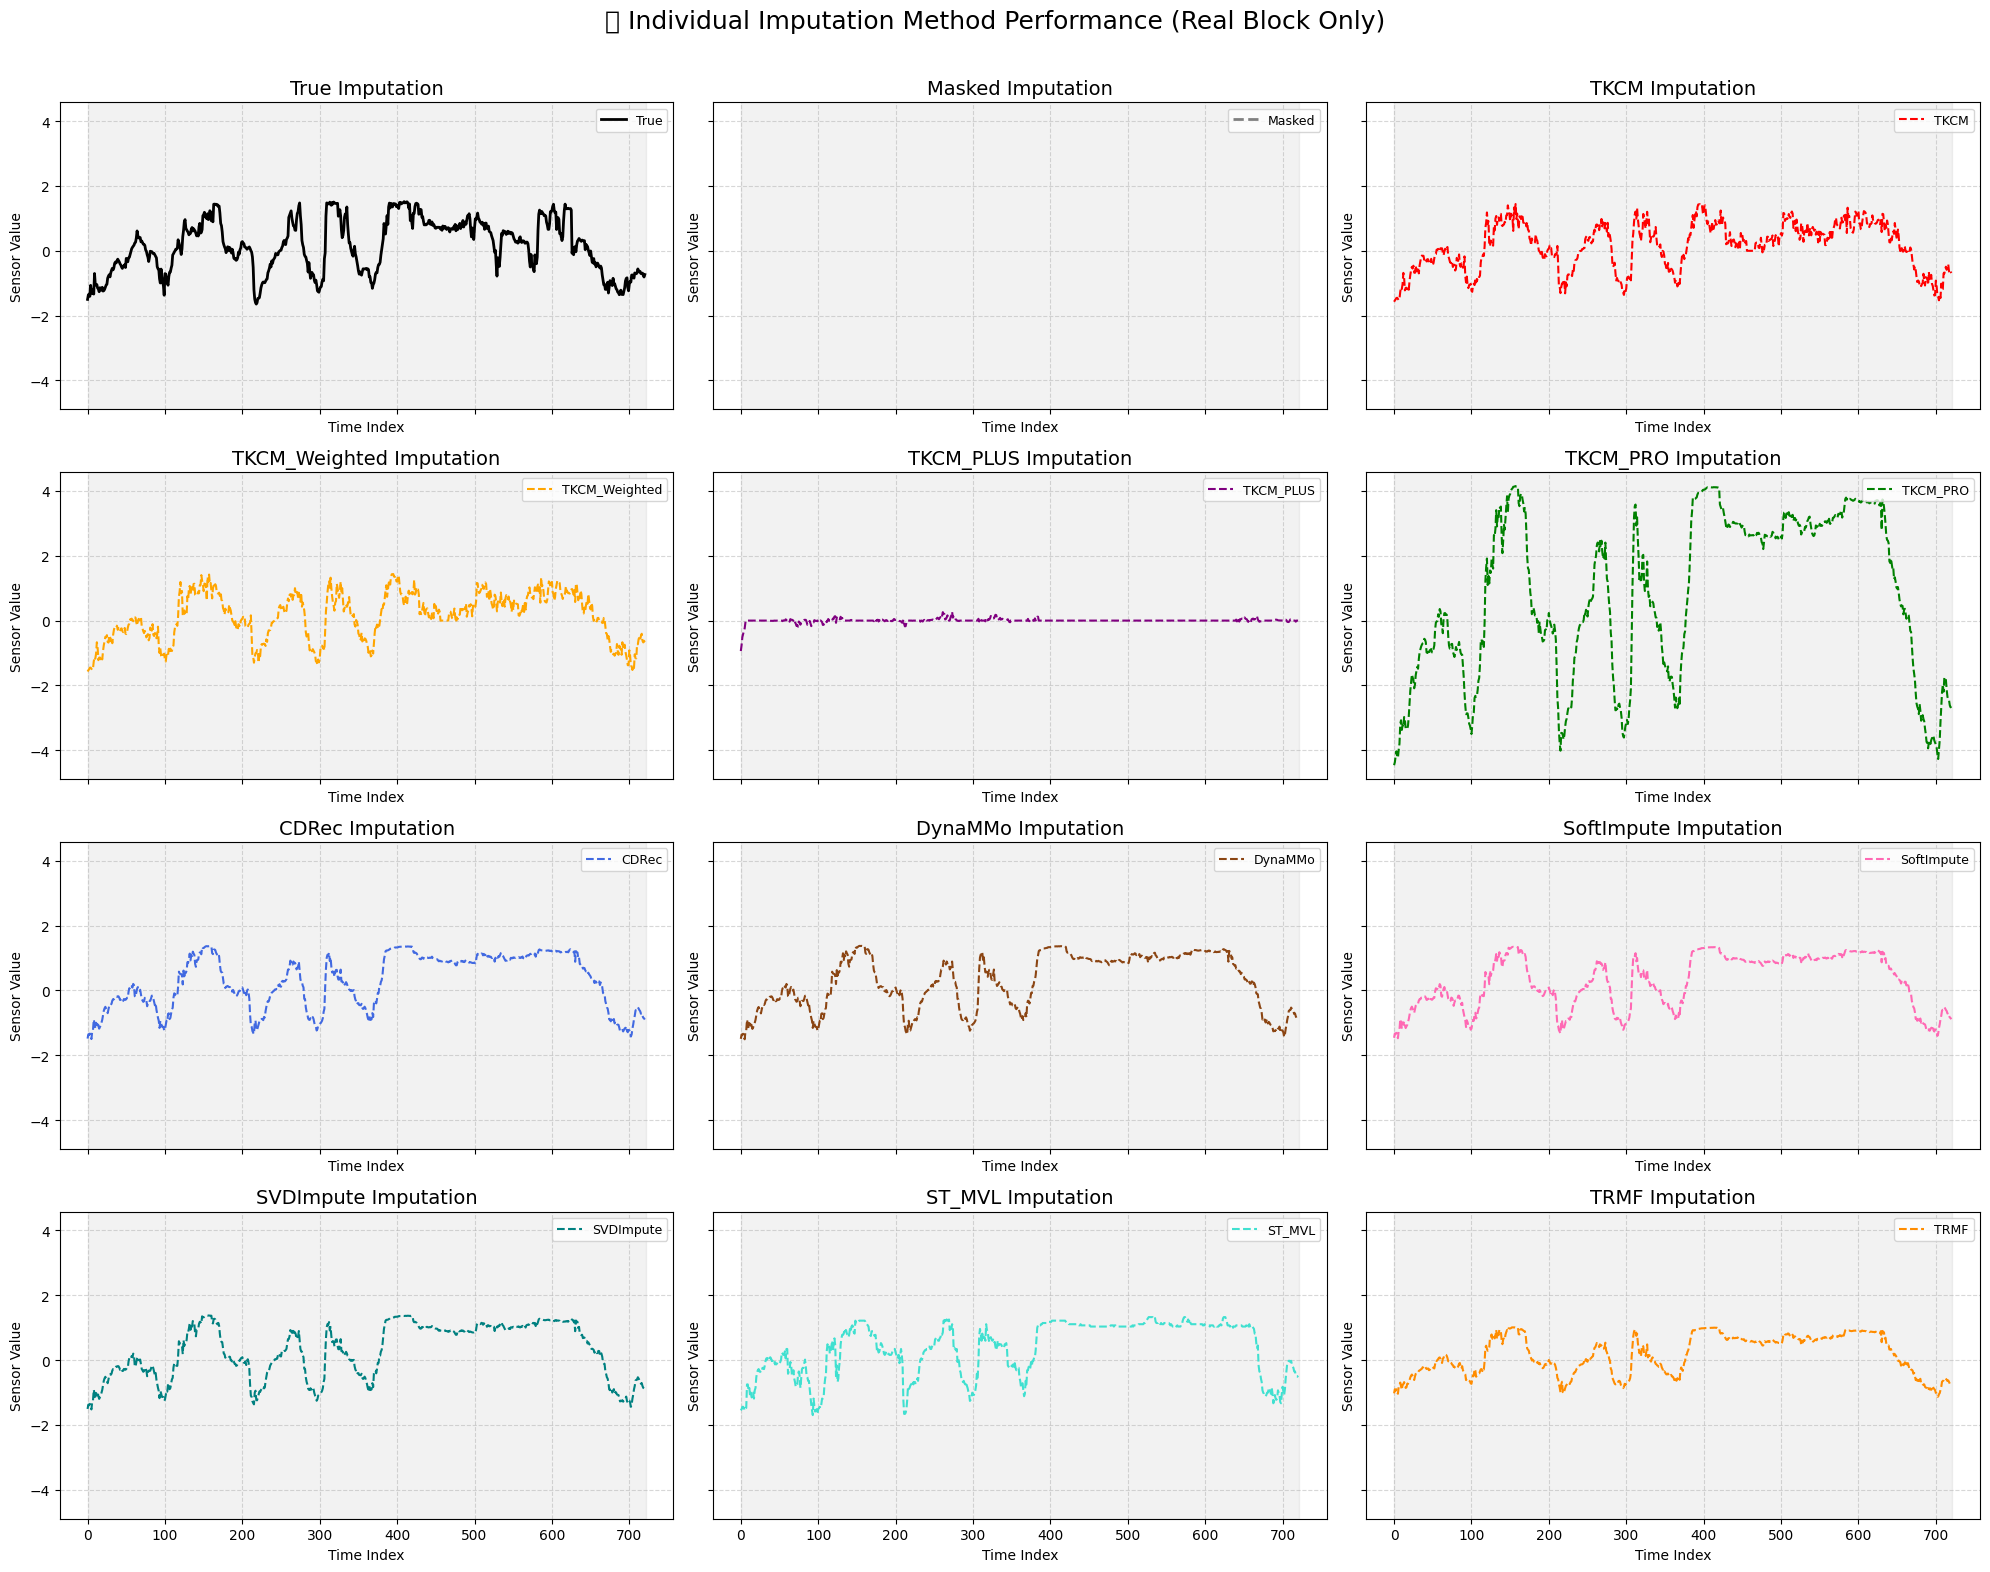

In [104]:
# 1. Define the real missing block range
block_start = start_idx
block_end = end_idx
block_length = block_end - block_start
time_block = np.arange(block_length)

# 2. Build a mapping with only the imputed block per method
imputed_data_block = {
    "True": true_target_array[block_start:block_end],
    "Masked": masked_target_array[block_start:block_end],
    "TKCM": tkcm_imputed[block_start:block_end],
    "TKCM_Weighted": tkcm_weighted_imputed[block_start:block_end],
    "TKCM_PLUS": tkcm_plus_imputed[block_start:block_end],
    "TKCM_PRO": tkcm_pro_imputed[block_start:block_end],
    "CDRec": cdrec_imputed[block_start:block_end],
    "DynaMMo": dynammo_imputed[block_start:block_end],
    "SoftImpute": soft_imputed[block_start:block_end],
    "SVDImpute": svd_imputed[block_start:block_end],
    "ST_MVL": st_mvl_imputed[block_start:block_end],
    "TRMF": trmf_imputed[block_start:block_end],
}

# 3. Plot settings
num_plots = len(imputed_data_block)
cols = 3
rows = (num_plots + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows), sharex=True, sharey=True)
axes = axes.flatten()

# Optional color/linestyle dicts
linestyles = {
    "True": "-",
    "Masked": "--"
}
colors = {
    "True": "black",
    "Masked": "gray",
    "TKCM": "red",
    "TKCM_Weighted": "orange",
    "TKCM_PLUS": "purple",
    "TKCM_PRO": "green",
    "CDRec": "royalblue",
    "DynaMMo": "saddlebrown",
    "SoftImpute": "hotpink",
    "SVDImpute": "teal",
    "ST_MVL": "turquoise",
    "TRMF": "darkorange"
}

# 4. Plot each method
for i, (method, series) in enumerate(imputed_data_block.items()):
    ax = axes[i]
    ax.plot(time_block, series,
            label=method,
            linestyle=linestyles.get(method, "--"),
            linewidth=2 if method in ["True", "Masked"] else 1.5,
            color=colors.get(method, "gray"))
    
    ax.axvspan(0, block_length, color="gray", alpha=0.1)
    ax.set_title(f"{method} Imputation", fontsize=14)
    ax.set_xlabel("Time Index")
    ax.set_ylabel("Sensor Value")
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc="upper right", fontsize=9)

# 5. Hide empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("📊 Individual Imputation Method Performance (Real Block Only)", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


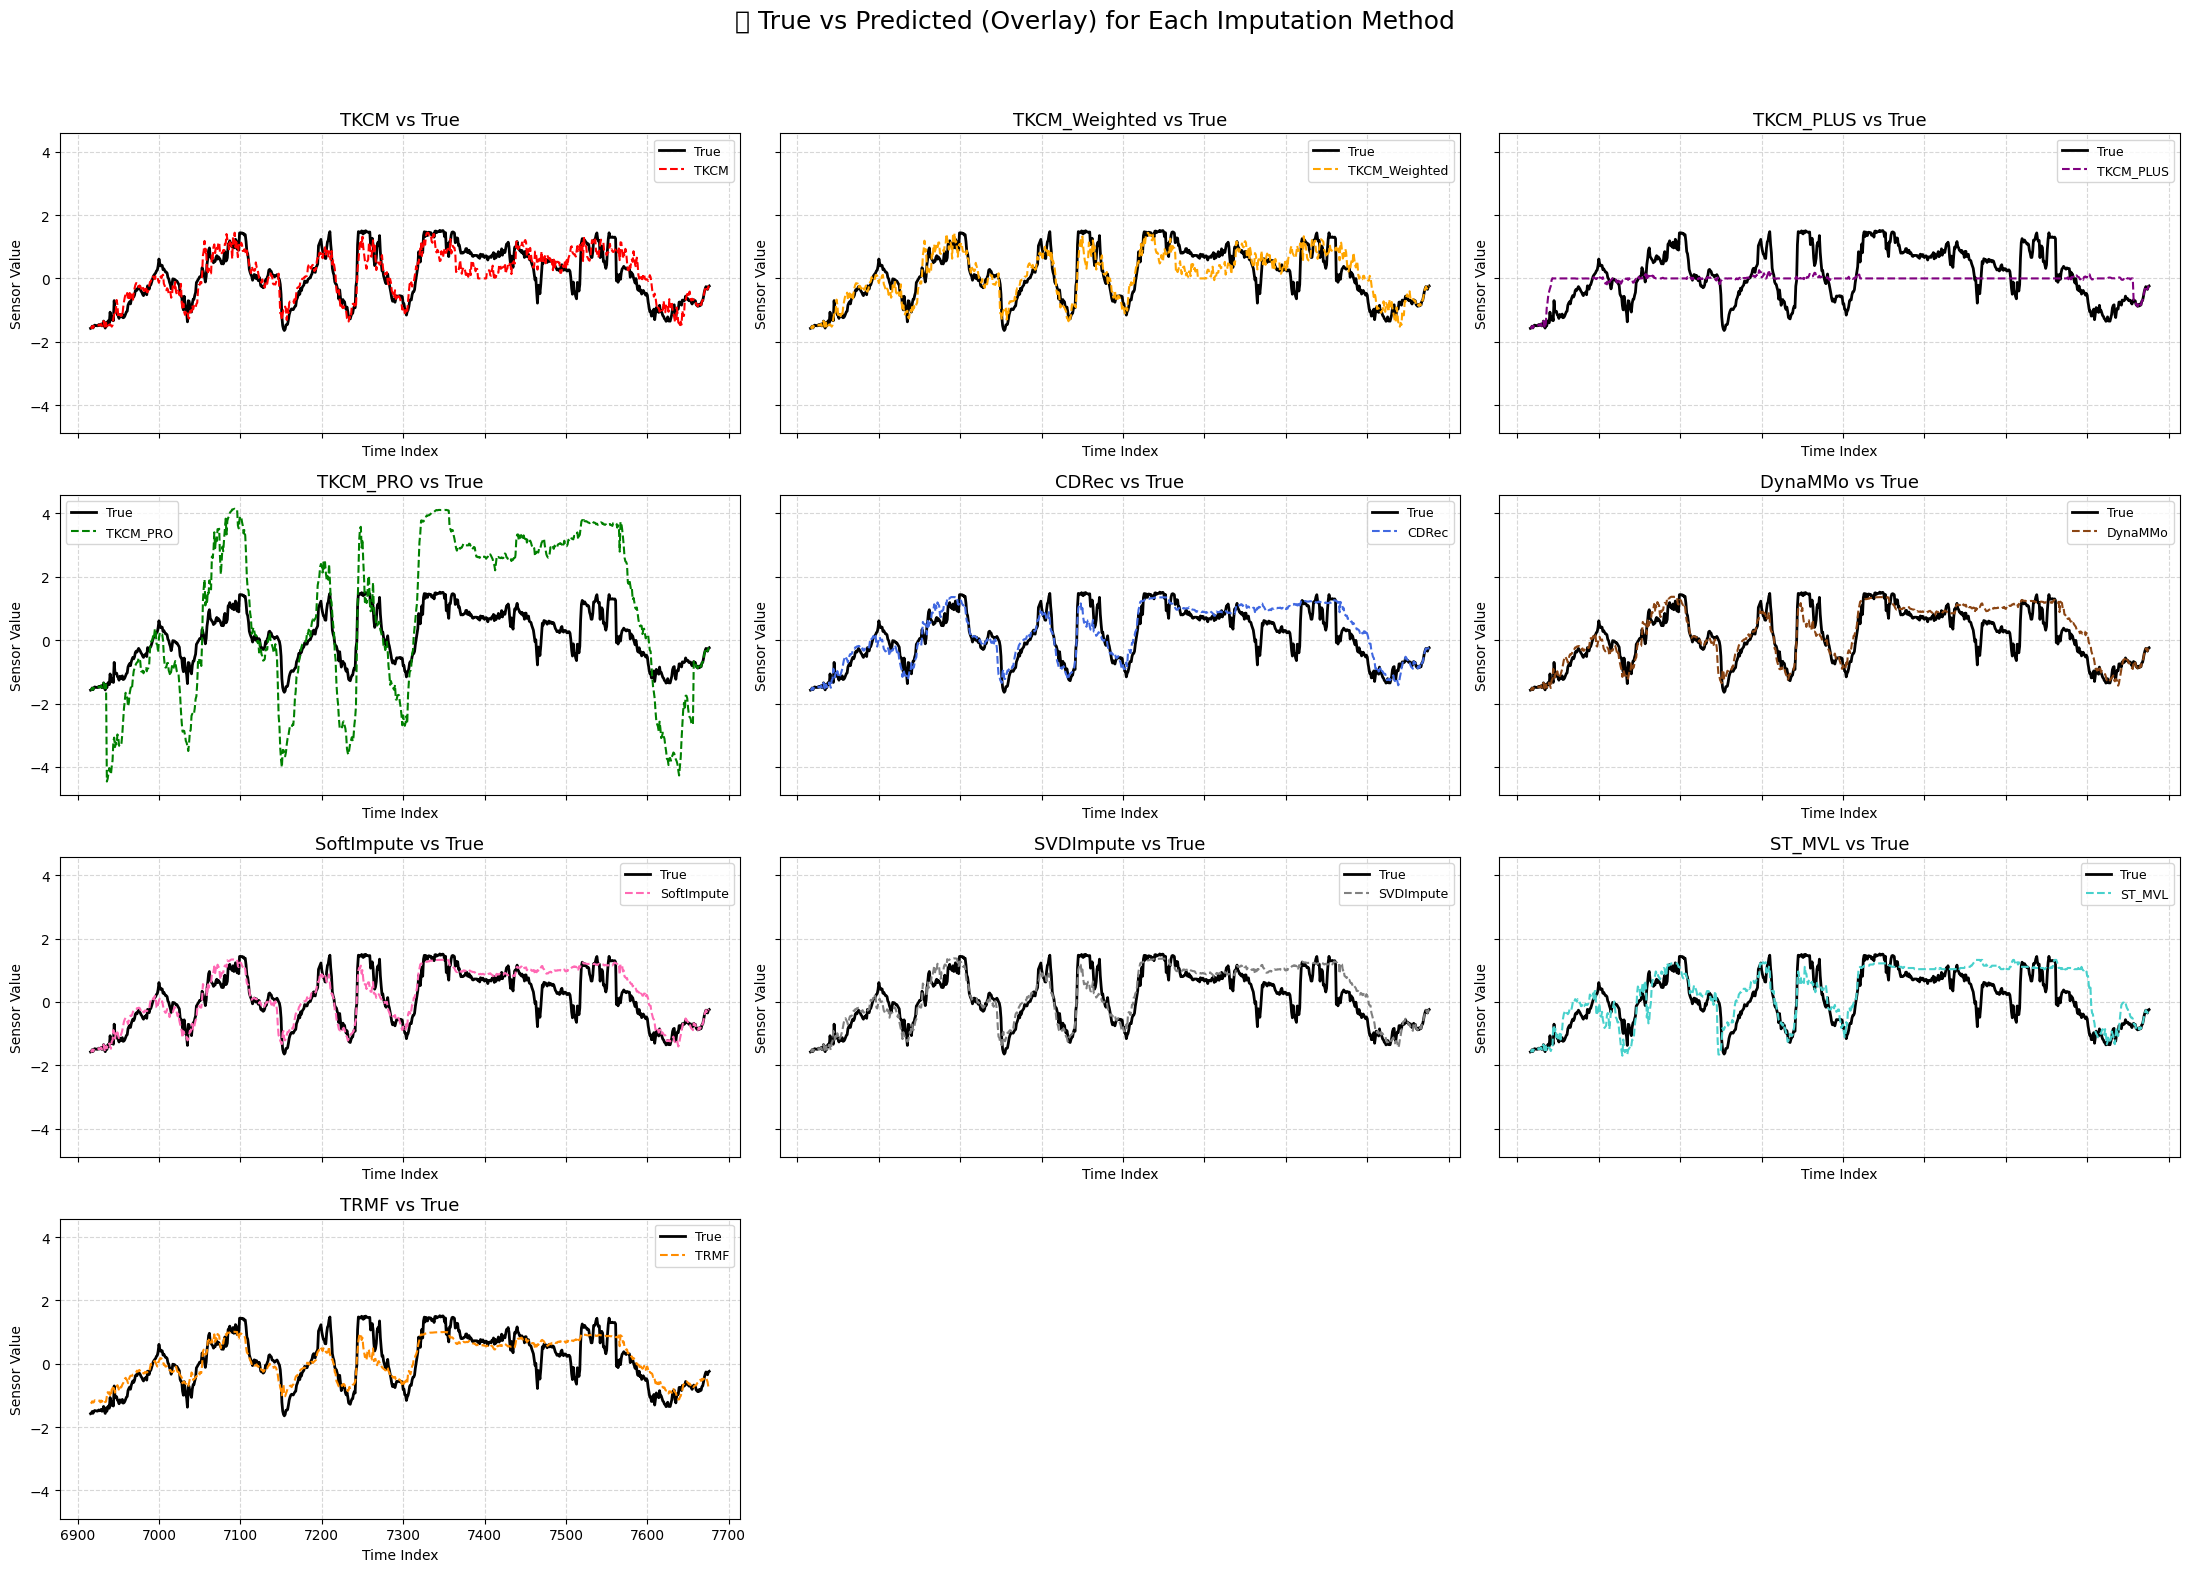

In [105]:
# Time axis for full-length series
time = np.arange(len(true_target_array))

# Define start and end of zoomed block
zoom_start = max(0, start_idx - 20)
zoom_end = min(len(true_target_array), end_idx + 20)
time_zoom = np.arange(zoom_start, zoom_end)

# Mapping for real imputation outputs
imputed_data_overlay = {
    "TKCM": tkcm_imputed,
    "TKCM_Weighted": tkcm_weighted_imputed,
    "TKCM_PLUS": tkcm_plus_imputed,
    "TKCM_PRO": tkcm_pro_imputed,
    "CDRec": cdrec_imputed,
    "DynaMMo": dynammo_imputed,
    "SoftImpute": soft_imputed,
    "SVDImpute": svd_imputed,
    "ST_MVL": st_mvl_imputed,
    "TRMF": trmf_imputed,
}

# Layout
num_plots = len(imputed_data_overlay)
cols = 3
rows = (num_plots + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(22, 4 * rows), sharex=True, sharey=True)
axes = axes.flatten()

# Colors per method
colors = {
    "TKCM": "red",
    "TKCM_Weighted": "orange",
    "TKCM_PLUS": "purple",
    "TKCM_PRO": "green",
    "CDRec": "royalblue",
    "DynaMMo": "saddlebrown",
    "SoftImpute": "hotpink",
    "SVDImpute": "gray",
    "ST_MVL": "mediumturquoise",
    "TRMF": "darkorange"
}

# Plot each method overlaid with True
for i, (method, imputed_series) in enumerate(imputed_data_overlay.items()):
    ax = axes[i]
    ax.plot(time[zoom_start:zoom_end], true_target_array[zoom_start:zoom_end], 
            label="True", color="black", linewidth=2)
    
    ax.plot(time[zoom_start:zoom_end], imputed_series[zoom_start:zoom_end], 
            label=method, linestyle="--", linewidth=1.5, color=colors.get(method, "gray"))
    
    ax.set_title(f"{method} vs True", fontsize=13)
    ax.set_xlabel("Time Index")
    ax.set_ylabel("Sensor Value")
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(fontsize=9)

# Hide unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("✅ True vs Predicted (Overlay) for Each Imputation Method", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


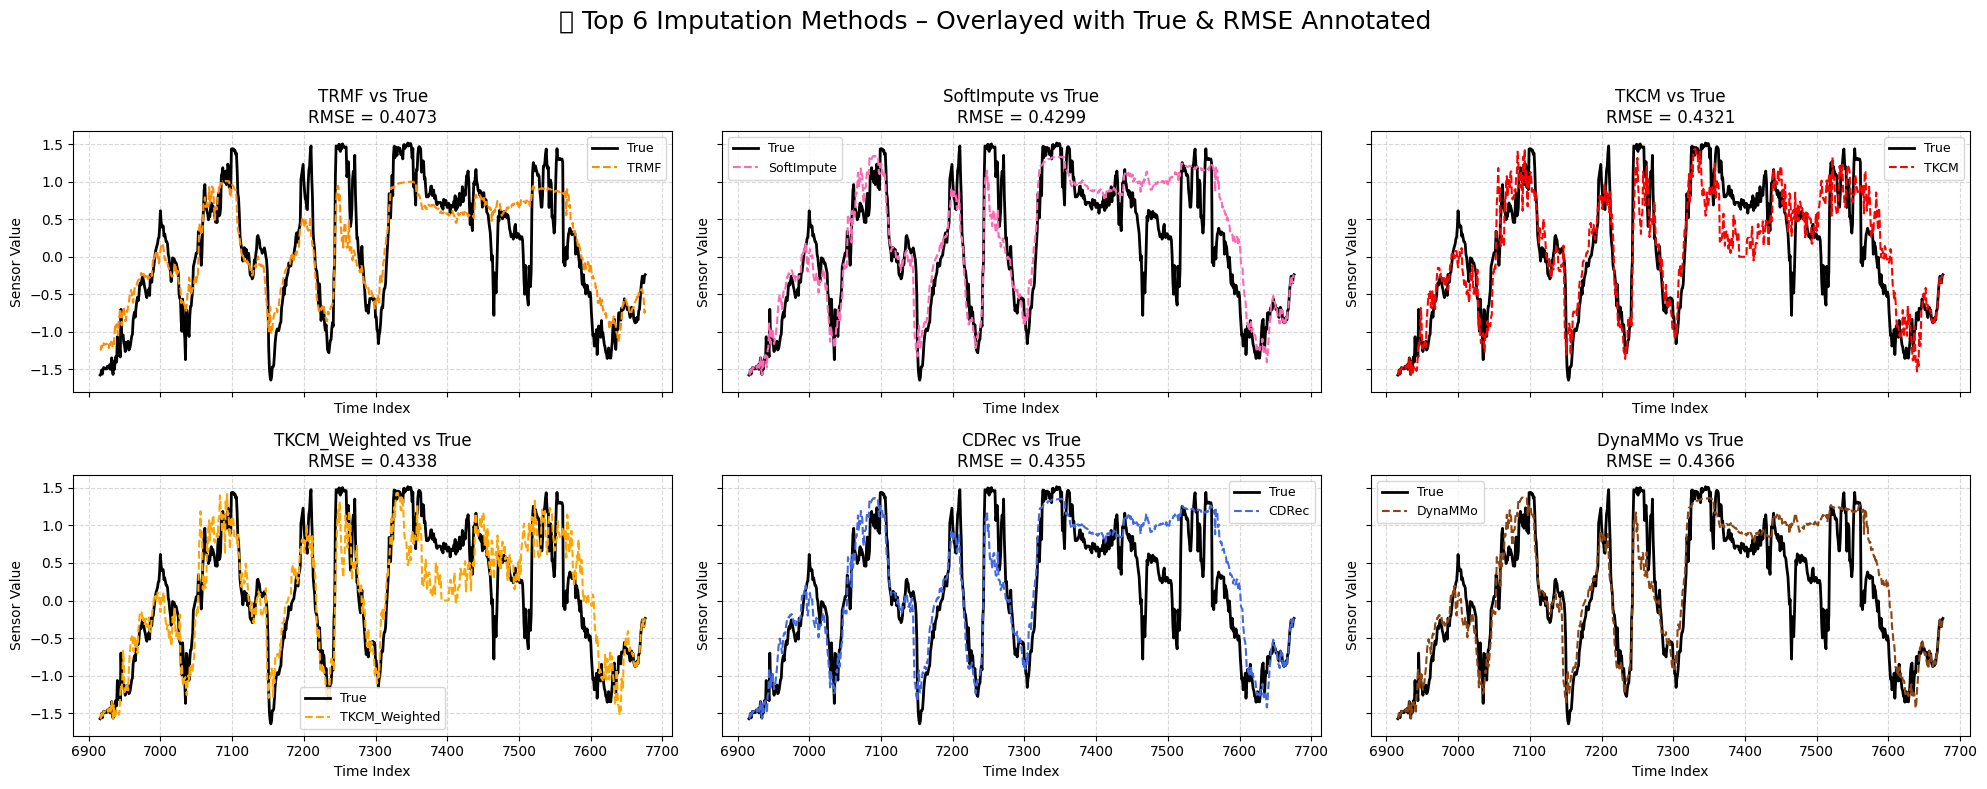

In [106]:
# ===== CONFIGURATION =====
top_k = 6         # Change to 6 for bottom 6 if needed
sort_order = "asc"  # "asc" for top-k, "desc" for bottom-k

# ===== FILTER TOP/BOTTOM K BASED ON RMSE =====
results_sorted = results_df.sort_values(by="RMSE", ascending=(sort_order == "asc"))
methods_to_plot = [m for m in results_sorted["Method"] if m not in ["True", "Masked"]][:top_k]

# ===== PREPARE PLOT RANGE =====
zoom_start = max(0, start_idx - 20)
zoom_end = min(len(true_target_array), end_idx + 20)
time = np.arange(len(true_target_array))

# ===== MAP OF IMPUTED SERIES =====
imputed_data_overlay = {
    "TKCM": tkcm_imputed,
    "TKCM_Weighted": tkcm_weighted_imputed,
    "TKCM_PLUS": tkcm_plus_imputed,
    "TKCM_PRO": tkcm_pro_imputed,
    "CDRec": cdrec_imputed,
    "DynaMMo": dynammo_imputed,
    "SoftImpute": soft_imputed,
    "SVDImpute": svd_imputed,
    "ST_MVL": st_mvl_imputed,
    "TRMF": trmf_imputed,
}

# ===== COLOR MAP (OPTIONAL) =====
colors = {
    "TKCM": "red", "TKCM_Weighted": "orange", "TKCM_PLUS": "purple", "TKCM_PRO": "green",
    "CDRec": "royalblue", "DynaMMo": "saddlebrown", "SoftImpute": "hotpink",
    "SVDImpute": "gray", "ST_MVL": "mediumturquoise", "TRMF": "darkorange"
}

# ===== PLOT CONFIG =====
cols = 3
rows = (len(methods_to_plot) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows), sharex=True, sharey=True)
axes = axes.flatten()

# ===== PLOT LOOP =====
for i, method in enumerate(methods_to_plot):
    ax = axes[i]
    pred = imputed_data_overlay[method][zoom_start:zoom_end]
    true = true_target_array[zoom_start:zoom_end]
    time_zoom = time[zoom_start:zoom_end]

    # Compute RMSE just for this zoomed window
    rmse = round(np.sqrt(np.mean((pred - true) ** 2)), 4)

    # Plot
    ax.plot(time_zoom, true, label="True", color="black", linewidth=2)
    ax.plot(time_zoom, pred, label=method, color=colors.get(method, "gray"), linestyle="--", linewidth=1.5)
    
    ax.set_title(f"{method} vs True\nRMSE = {rmse}", fontsize=12)
    ax.set_xlabel("Time Index")
    ax.set_ylabel("Sensor Value")
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(fontsize=9)

# ===== CLEANUP UNUSED AXES =====
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# ===== FINAL TITLE =====
title_msg = "Top" if sort_order == "asc" else "Bottom"
plt.suptitle(f"📊 {title_msg} {top_k} Imputation Methods – Overlayed with True & RMSE Annotated", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


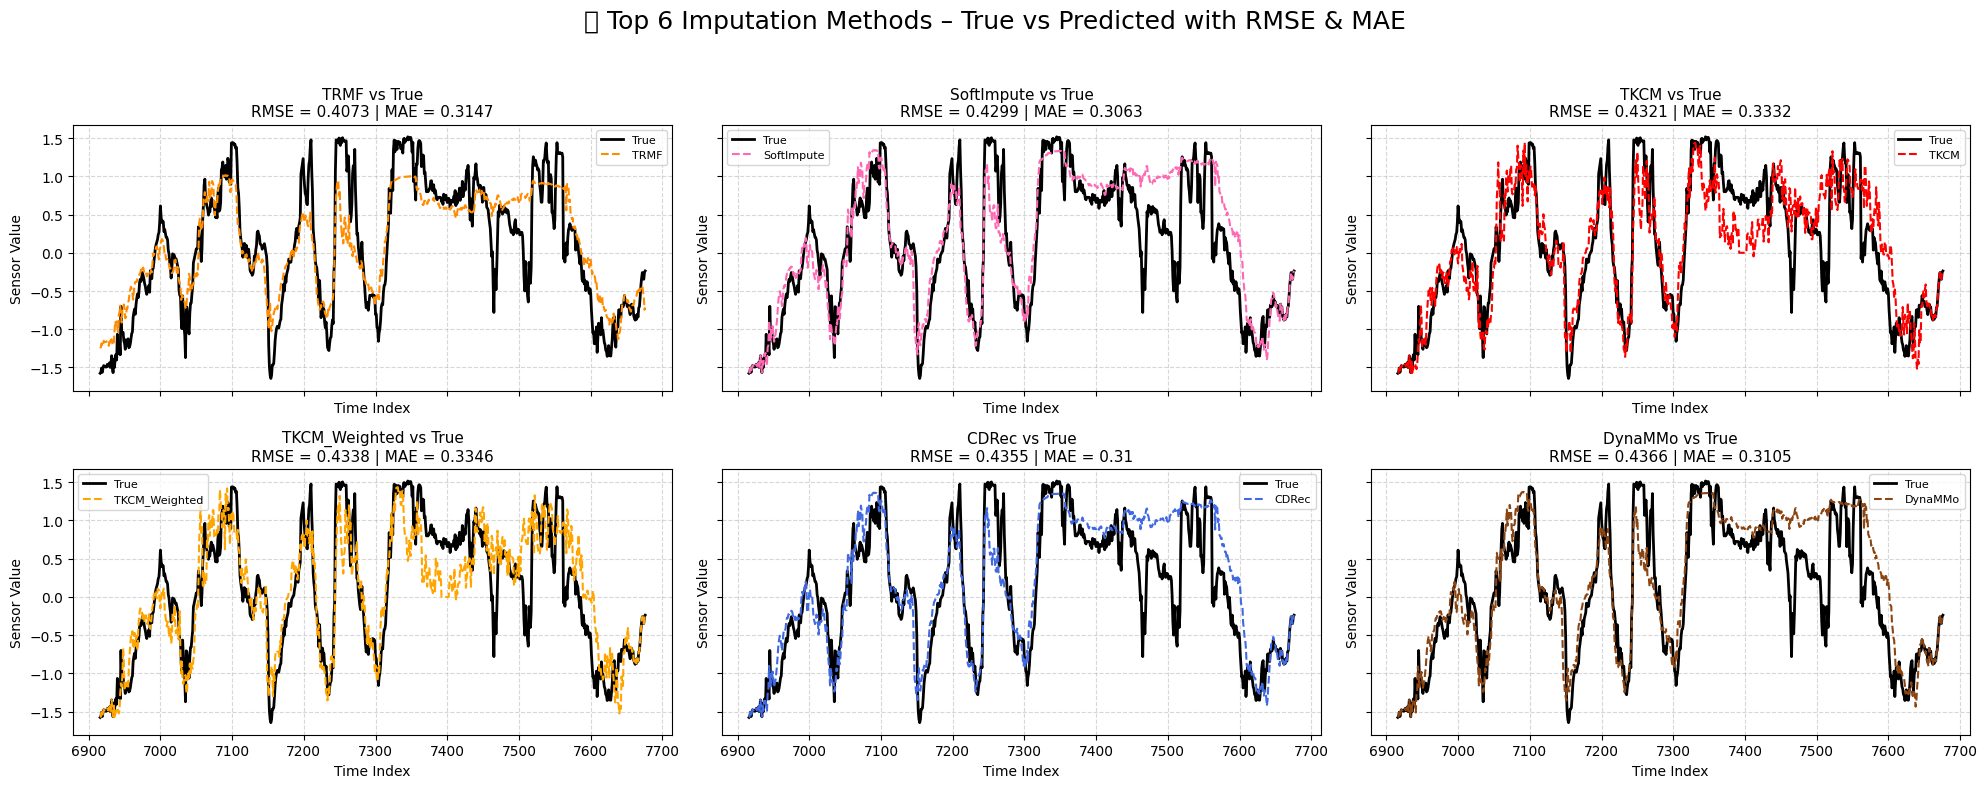

In [107]:
# ===== CONFIGURATION =====
top_k = 6         # Change this for how many methods to show
sort_order = "asc"  # "asc" for top-k, "desc" for bottom-k

# ===== FILTER TOP/BOTTOM K BASED ON RMSE =====
results_sorted = results_df.sort_values(by="RMSE", ascending=(sort_order == "asc"))
methods_to_plot = [m for m in results_sorted["Method"] if m not in ["True", "Masked"]][:top_k]

# ===== PLOT RANGE AND TIME AXIS =====
zoom_start = max(0, start_idx - 20)
zoom_end = min(len(true_target_array), end_idx + 20)
time = np.arange(len(true_target_array))
time_zoom = time[zoom_start:zoom_end]

# ===== MAP OF IMPUTED SERIES =====
imputed_data_overlay = {
    "TKCM": tkcm_imputed,
    "TKCM_Weighted": tkcm_weighted_imputed,
    "TKCM_PLUS": tkcm_plus_imputed,
    "TKCM_PRO": tkcm_pro_imputed,
    "CDRec": cdrec_imputed,
    "DynaMMo": dynammo_imputed,
    "SoftImpute": soft_imputed,
    "SVDImpute": svd_imputed,
    "ST_MVL": st_mvl_imputed,
    "TRMF": trmf_imputed,
}

# ===== COLOR MAP =====
colors = {
    "TKCM": "red", "TKCM_Weighted": "orange", "TKCM_PLUS": "purple", "TKCM_PRO": "green",
    "CDRec": "royalblue", "DynaMMo": "saddlebrown", "SoftImpute": "hotpink",
    "SVDImpute": "gray", "ST_MVL": "mediumturquoise", "TRMF": "darkorange"
}

# ===== SUBPLOT SETUP =====
cols = 3
rows = (len(methods_to_plot) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows), sharex=True, sharey=True)
axes = axes.flatten()

# ===== PLOTTING LOOP =====
for i, method in enumerate(methods_to_plot):
    ax = axes[i]
    pred = imputed_data_overlay[method][zoom_start:zoom_end]
    true = true_target_array[zoom_start:zoom_end]

    # Calculate RMSE and MAE
    rmse = round(np.sqrt(np.mean((pred - true) ** 2)), 4)
    mae = round(np.mean(np.abs(pred - true)), 4)

    # Plot
    ax.plot(time_zoom, true, label="True", color="black", linewidth=2)
    ax.plot(time_zoom, pred, label=method, color=colors.get(method, "gray"), linestyle="--", linewidth=1.5)

    ax.set_title(f"{method} vs True\nRMSE = {rmse} | MAE = {mae}", fontsize=11)
    ax.set_xlabel("Time Index")
    ax.set_ylabel("Sensor Value")
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(fontsize=8)

# ===== REMOVE UNUSED SUBPLOTS =====
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# ===== FINAL TITLE =====
title_msg = "Top" if sort_order == "asc" else "Bottom"
plt.suptitle(f"📊 {title_msg} {top_k} Imputation Methods – True vs Predicted with RMSE & MAE", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [111]:
# --- TKCM + TKCM_Weighted Manual Grid ---
results_block = []

# ===== Try any values you want =====
k = 16
l = 14

true_vals = true_target_array[start_idx:end_idx]
missing_indices = np.arange(start_idx, end_idx)

def evaluate_direct(name, imputed_array):
    try:
        predicted = imputed_array[start_idx:end_idx]
        mae = np.mean(np.abs(predicted - true_vals))
        rmse = np.sqrt(np.mean((predicted - true_vals) ** 2))
        results_block.append({
            "Method": name,
            "k": k,
            "l": l,
            "MAE": round(mae, 4),
            "RMSE": round(rmse, 4)
        })
    except:
        results_block.append({
            "Method": name,
            "k": k,
            "l": l,
            "MAE": "NaN",
            "RMSE": "NaN"
        })

# TKCM
try:
    tkcm_imputed = masked_target_array.copy()
    for offset in missing_indices:
        tkcm_imputed = TKCM(k=k, l=l).impute(tkcm_imputed, offset=offset, ref_ts=ref_matrix)
    evaluate_direct("TKCM", tkcm_imputed)
except Exception as e:
    print("TKCM failed:", e)
    evaluate_direct("TKCM", np.full_like(true_vals, np.nan))

# TKCM_Weighted
try:
    tkcm_weighted_imputed = masked_target_array.copy()
    for offset in missing_indices:
        tkcm_weighted_imputed = TKCM_Weighted(k=k, l=l).impute(
            tkcm_weighted_imputed, offset=offset, ref_ts=ref_matrix)
    evaluate_direct("TKCM_Weighted", tkcm_weighted_imputed)
except Exception as e:
    print("TKCM_Weighted failed:", e)
    evaluate_direct("TKCM_Weighted", np.full_like(true_vals, np.nan))

# Display
results_df = pd.DataFrame(results_block)
display(results_df)


,Method,k,l,MAE,RMSE
0,TKCM,16,14,0.3024,0.3941
1,TKCM_Weighted,16,14,0.3039,0.3938


TKCM and Weighted_TKCM Outperformed other algorithms

In [112]:
# --- TKCM_PLUS + TKCM_PRO Manual Grid ---
results_block = []

# ===== Try your manual values here =====
k = 10
l = 8
alpha = 0.7
beta = 0.3

true_vals = true_target_array[start_idx:end_idx]
missing_indices = np.arange(start_idx, end_idx)

def evaluate_direct(name, imputed_array):
    try:
        predicted = imputed_array[start_idx:end_idx]
        mae = np.mean(np.abs(predicted - true_vals))
        rmse = np.sqrt(np.mean((predicted - true_vals) ** 2))
        results_block.append({
            "Method": name,
            "k": k,
            "l": l,
            "alpha": alpha if "PLUS" in name else None,
            "beta": beta if "PLUS" in name else None,
            "MAE": round(mae, 4),
            "RMSE": round(rmse, 4)
        })
    except:
        results_block.append({
            "Method": name,
            "k": k,
            "l": l,
            "alpha": alpha if "PLUS" in name else None,
            "beta": beta if "PLUS" in name else None,
            "MAE": "NaN",
            "RMSE": "NaN"
        })

# TKCM_PLUS
try:
    tkcm_plus_imputed = masked_target_array.copy()
    for offset in missing_indices:
        tkcm_plus_imputed = TKCM_PLUS(k=k, l=l, alpha=alpha, beta=beta).impute(
            tkcm_plus_imputed, offset=offset, ref_ts=ref_matrix)
    evaluate_direct("TKCM_PLUS", tkcm_plus_imputed)
except Exception as e:
    print("TKCM_PLUS failed:", e)
    evaluate_direct("TKCM_PLUS", np.full_like(true_vals, np.nan))

# TKCM_PRO
try:
    tkcm_pro_imputed = masked_target_array.copy()
    for offset in missing_indices:
        tkcm_pro_imputed = TKCM_PRO(k=k, l=l).impute(
            tkcm_pro_imputed, offset=offset, ref_ts=ref_matrix)
    evaluate_direct("TKCM_PRO", tkcm_pro_imputed)
except Exception as e:
    print("TKCM_PRO failed:", e)
    evaluate_direct("TKCM_PRO", np.full_like(true_vals, np.nan))

# Display
results_df = pd.DataFrame(results_block)
display(results_df)


,Method,k,l,alpha,beta,MAE,RMSE
0,TKCM_PLUS,10,8,0.7,0.3,0.4427,0.5511
1,TKCM_PRO,10,8,NaN,NaN,1.6776,1.9330
